In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as pltt
from matplotlib import cm
from matplotlib import rc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import warnings
from adjustText import adjust_text
warnings.simplefilter('ignore')
import plotting_functions as pf

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 1000)

pd.set_option("display.float_format", "{:.4f}".format)

#for export of consolidaed data to docx 
from docx import Document
from docx.shared import Mm
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.shared import Pt, RGBColor
from docx.enum.text import WD_UNDERLINE
from docx.enum.text import WD_COLOR_INDEX
from docx.enum.section import WD_ORIENT

import json
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from tqdm import tqdm
import os

# Data load

In [2]:
df_opt = pd.read_csv(r'base_data\PhNH2_BnOH.csv', sep = '\t') #data exclusively on PhNH2 and BnOH reaction including optimization data
df_nitro = pd.read_csv(r'base_data\PhNO2_BnOH.csv', sep = '\t') #data exclusively on PhNO2 and BnOH reaction including optimization data
df_substr = pd.read_csv(r'base_data\substrates.csv', sep = '\t') #data on substrate scope. Covers both nitro and amines
df_meoh = pd.read_csv(r'base_data\MeOH.csv', sep = '\t') #data on alkylation usong MeOH

#### Important note: in all cases successful reaction means the yield > 65%.

In [3]:
df_opt.shape, df_nitro.shape, df_substr.shape, df_meoh.shape

((3439, 24), (307, 21), (9201, 24), (388, 25))

In [4]:
df_substr.columns

Index(['doi', 'solvent', 'amine_type', 'pKa_amine', 'n_amine', 'alcohol_type',
       'pKa_alcohol', 'n_alcohol', 'base', 'base_amount', 'catalyst', 'metal',
       'ligand', 'atmosphere', 'metal_load', 'temp', 'time', 'yield', 'TON',
       'atm_type', 'year', 'base_amine_ratio', 'base_alcohol_ratio',
       'reag_ratio'],
      dtype='str')

In [5]:
df_opt.columns

Index(['doi', 'solvent', 'PhNH2', 'BnOH', 'alc2aniline_ratio', 'base',
       'base_amount', 'catalyst', 'metal', 'ligand', 'atmosphere', 'cat_load',
       'temp', 'time', 'yield', 'TON', 'comment', 'success', 'atm_type',
       'year', 'base_amine_ratio', 'base_alcohol_ratio', 'num_temp_range',
       'label_temp_range'],
      dtype='str')

In [6]:
df_substr['amine_type'].value_counts()

amine_type
Aromatic        5234
Aliphatic       1323
Hetaromatic     1073
ArNO2            607
Sulfonamide      382
Ammonia          184
Amide            153
Alk2NH            56
HetAromatic       37
amide             34
NH4OAc            28
Sulfinamide       26
SulfonamideK      12
ArAlkNH           11
AlkNO2            11
Ph2NH              9
NH4BF4             9
HCOONH4            8
HetNO2             4
Name: count, dtype: int64

In [7]:
df_substr['alcohol_type'].value_counts()

alcohol_type
BnOH          5339
AlkCH2OH      1537
ArCH2OH        683
MeOH           662
Alk2CHOH       456
AlkArCHOH      260
Bn2OH          110
HetBnOH         74
AllOH           49
AlkEWGCHOH      11
FcOH            10
ArEWGCHOH        6
EWGCH2OH         4
Name: count, dtype: int64

# Borrowing hydrogen amination

In [8]:
#only BH reactions
nitro = ['ArNO2', 'AlkNO2', 'HetNO2']
df_substr_hb = df_substr[~df_substr['amine_type'].isin(nitro)]
df_substr_hb.shape

(8579, 24)

## Catalyst's activity and metals usage

In [9]:
cat_df = pd.concat([
    df_opt[['doi', 'catalyst', 'metal', 'ligand', 'yield', 'cat_load', 'TON', 'base', 'atm_type', 'year']],
    df_substr_hb[['doi', 'catalyst', 'metal', 'ligand', 'yield', 'metal_load', 'TON', 'base', 'atm_type', 'year']].rename(columns = {'metal_load': 'cat_load'})
])
cat_df.dropna(subset = 'TON', inplace = True)
cat_df.dropna(subset = 'metal', inplace = True)
cat_df = cat_df[cat_df['metal'].apply(lambda x: len(x.split(',')) == 1)].copy()
cat_df = cat_df[cat_df['cat_load'] > 0]
cat_df = cat_df[cat_df['TON'] > 5].copy()
cat_df.sort_values(by = 'TON', ascending = False, inplace = True)
cat_df.drop_duplicates(subset = ['catalyst', 'ligand', 'doi'], inplace = True)
cat_df.reset_index(drop = True, inplace = True)
print(f'We have {cat_df.shape[0]} different catalysts')

We have 924 different catalysts


In [10]:
def get_activity(ton):
    if ton >=500:
        return 'active'
    elif ton>=100:
        return 'medium'
    else:
        return 'low'

cat_df['activity'] = cat_df['TON'].apply(get_activity)

In [11]:
cat_df.head()

,doi,catalyst,metal,ligand,yield,cat_load,TON,base,atm_type,year,activity
0,10.1016/j.ica.2023.121546,Cu-BTC,Cu,0,14.0000,15.0000,inf,NaHCO3,oxygen,2023,active
1,10.1016/j.tet.2017.03.001,Pd2((AcO)pirazoleAr3)2,Pd,"P(2-Fu)3 (0,4 mol%), 4A MS",89.0000,0.0020,44500.0000,LiOH,inert,2017,active
2,10.1002/adsc.201701117,"Ru(1,10-phenanthroline)Py(PPh3)2(PF6)",Ru,no,42.8400,0.0010,42840.0000,tBuOK,inert,2017,active
3,10.1021/acs.inorgchem.9b03049,RuNHC,Ru,no,33.0000,0.0010,33000.0000,tBuOK,inert,2020,active
4,10.1021/acs.organomet.0c00233,NiNNN,Ni,no,68.0000,0.0021,32640.0052,tBuONa,inert,2020,active


In [12]:
#catalysts before 2022
cat_df.loc[cat_df['year']<2022]['activity'].value_counts()

activity
low       443
medium    121
active     36
Name: count, dtype: int64

In [13]:
# whole data on catalysts
cat_df['activity'].value_counts()

activity
low       696
medium    169
active     59
Name: count, dtype: int64

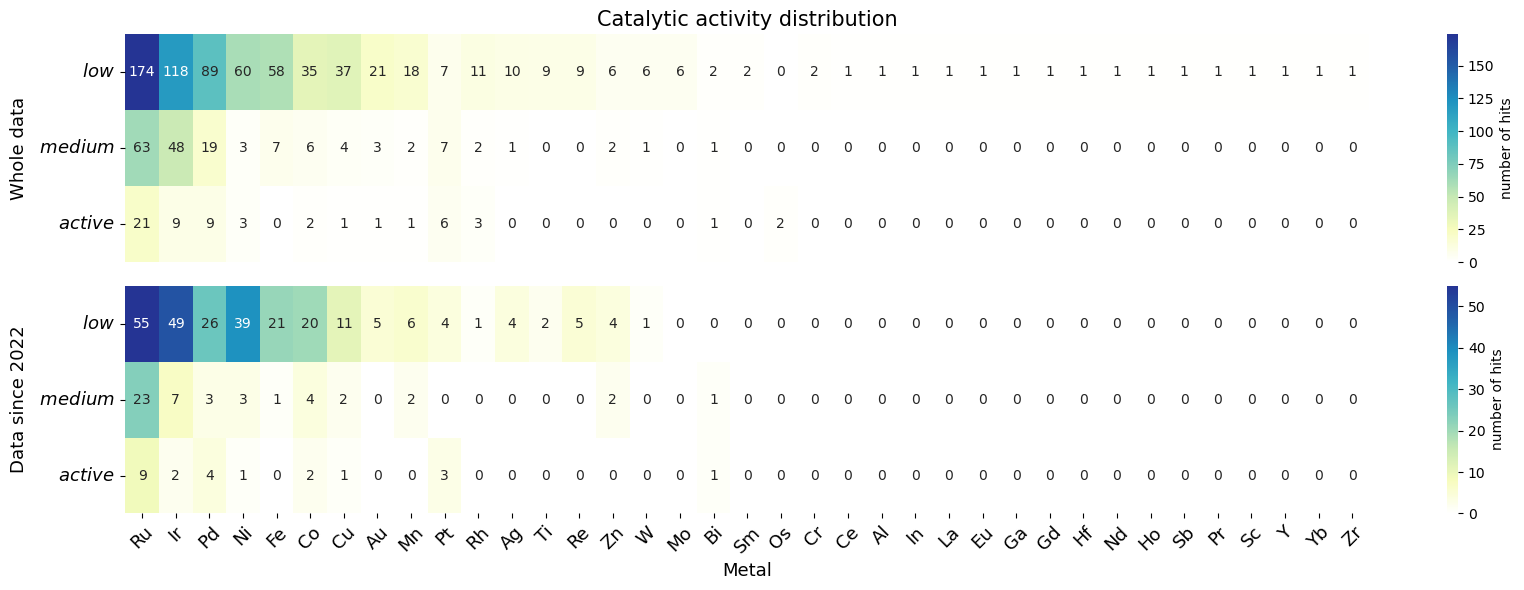

In [14]:
pf.plot_diff_graph(    
    cat_df, 
    'activity', 
    'metal',
    filter_val = 0,
    figsize = (17, 6),
    xlabel = 'Metal',
    title = 'Catalytic activity distribution'   
)

In [15]:
cat_df = pd.concat([
    df_opt[['doi', 'catalyst', 'metal', 'ligand', 'yield', 'cat_load', 'TON', 'base', 'atm_type', 'year']],
    df_substr_hb[['doi', 'catalyst', 'metal', 'ligand', 'yield', 'metal_load', 'TON', 'base', 'atm_type', 'year']].rename(columns = {'metal_load': 'cat_load'})
])
cat_df['success'] = cat_df['yield'] > 65
metals_full = cat_df[cat_df['success']]['metal'].value_counts()
metals_new = cat_df.loc[(cat_df['success']) & (cat_df['year']>=2022)]['metal'].value_counts()
df_metals = pd.concat([metals_full, metals_new ], axis = 1)
df_metals.columns = ['full data', 'data since 2022']
df_metals[df_metals.index.isin([x for x in df_metals.index if len(x.split(','))==1])]

,full data,data since 2022
metal,,
Ru,1914,504.0000
Ir,1536,358.0000
Co,576,317.0000
Pd,571,103.0000
Ni,556,222.0000
Cu,436,207.0000
Fe,384,62.0000
Mn,322,79.0000
Rh,148,1.0000


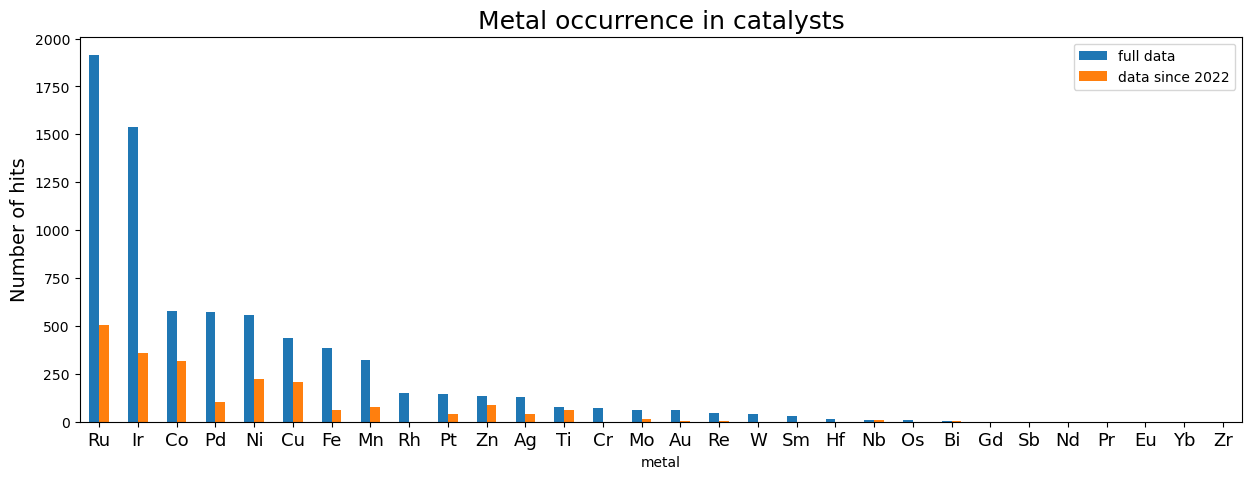

In [16]:
ax=df_metals[df_metals.index.isin([x for x in df_metals.index if len(x.split(','))==1])].plot(kind='bar', figsize=(15,5))

ax.set_ylabel('Number of hits', fontsize = 14)
ax.set_title('Metal occurrence in catalysts', fontsize = 18)
plt.xticks(fontsize=13, rotation='horizontal');

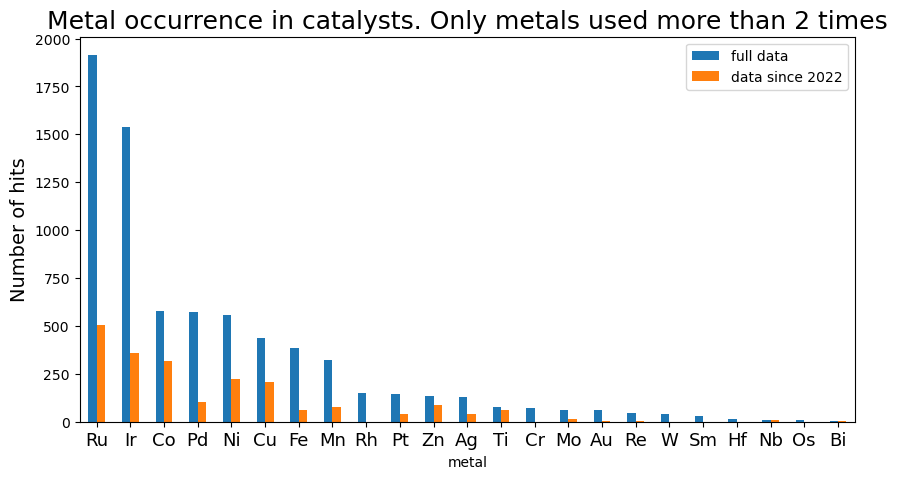

In [17]:
ax=df_metals.loc[
    (df_metals.index.isin([x for x in df_metals.index if len(x.split(','))==1])) &
    (df_metals['full data'] > 2)
    ].plot(kind='bar', figsize=(10,5))

ax.set_ylabel('Number of hits', fontsize = 14)
ax.set_title('Metal occurrence in catalysts. Only metals used more than 2 times', fontsize = 18)
plt.xticks(fontsize=13, rotation='horizontal');

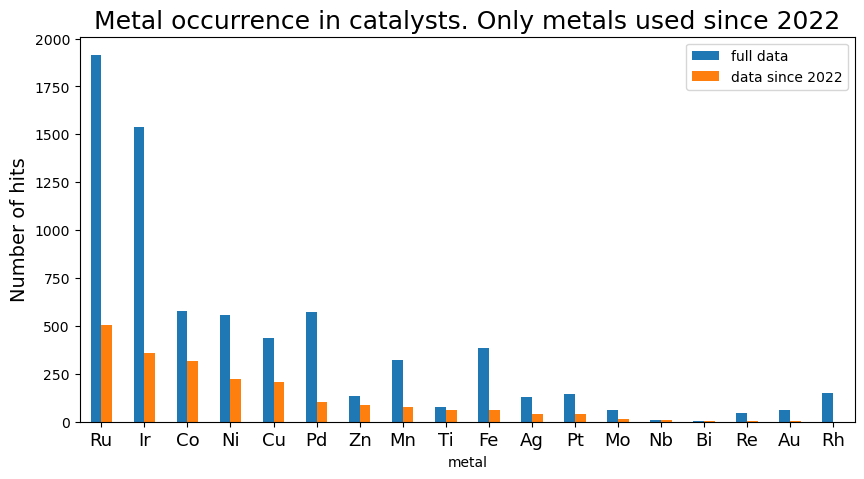

In [18]:
ax=df_metals.loc[
    (df_metals.index.isin([x for x in df_metals.index if len(x.split(','))==1])) &
    (df_metals['data since 2022'] >= 1)    
    ].sort_values(by = 'data since 2022', ascending = False).plot(kind='bar', figsize=(10,5))

ax.set_ylabel('Number of hits', fontsize = 14)
ax.set_title('Metal occurrence in catalysts. Only metals used since 2022', fontsize = 18)
plt.xticks(fontsize=13, rotation='horizontal');

## Comparison of metal-catalyzed and transition metal-free reaction

In [19]:
benchmark_yield = 65 # this is an yield of the reaction to consider it successful.
df_substr_hb_succ = df_substr_hb[df_substr_hb['yield'] > benchmark_yield]
df_opt_succ = df_opt[df_opt['yield'] > benchmark_yield] 

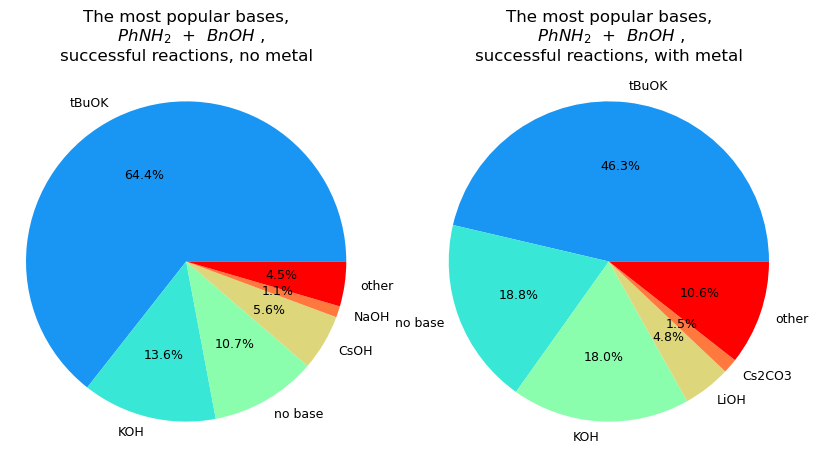

In [20]:
pf.compare_pie(df_opt_succ, 'base', [f'The most popular bases,\n {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')},\nsuccessful reactions, no metal',
                                 f'The most popular bases,\n{pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')},\nsuccessful reactions, with metal'])

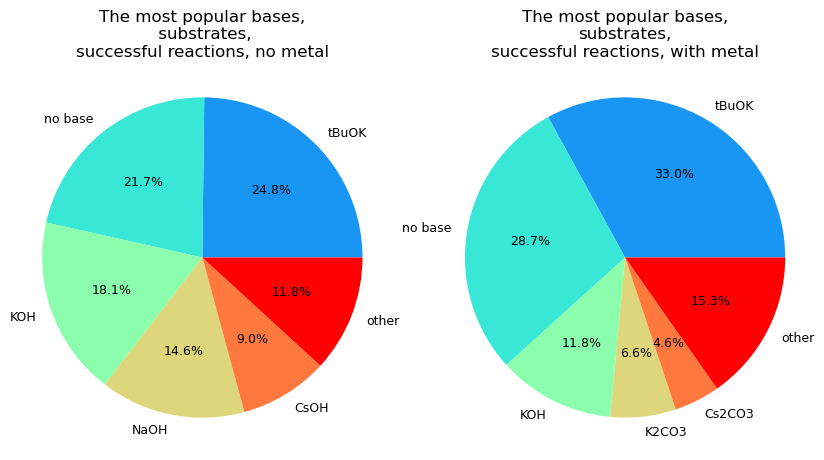

In [21]:
pf.compare_pie(df_substr_hb_succ, 'base', [f'The most popular bases,\n substrates,\nsuccessful reactions, no metal',
                                 f'The most popular bases,\nsubstrates,\nsuccessful reactions, with metal'])

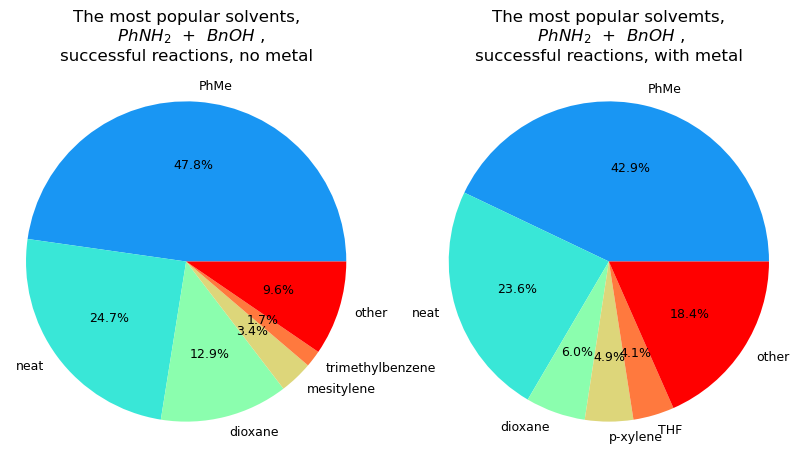

In [22]:
pf.compare_pie(df_opt_succ, 'solvent', [f'The most popular solvents,\n {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')},\nsuccessful reactions, no metal',
                                 f'The most popular solvemts,\n{pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')},\nsuccessful reactions, with metal'],
              limit_items = 5)

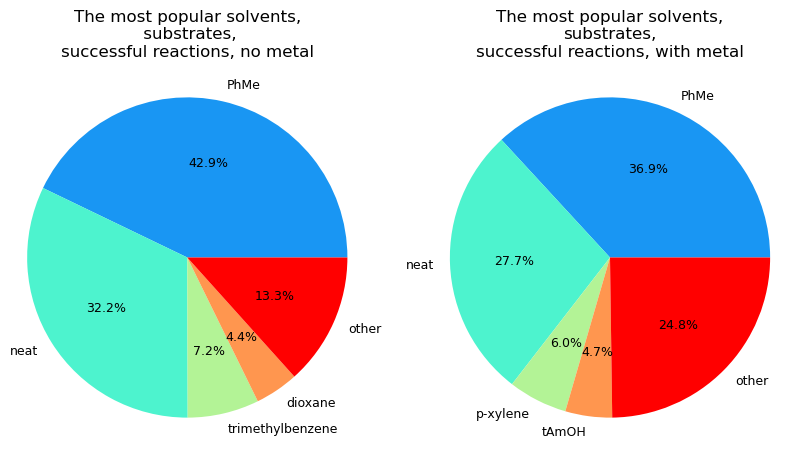

In [23]:
pf.compare_pie(df_substr_hb_succ, 'solvent', [f'The most popular solvents,\n substrates,\nsuccessful reactions, no metal',
                                 f'The most popular solvents,\nsubstrates,\nsuccessful reactions, with metal'], 
              limit_items = 4)

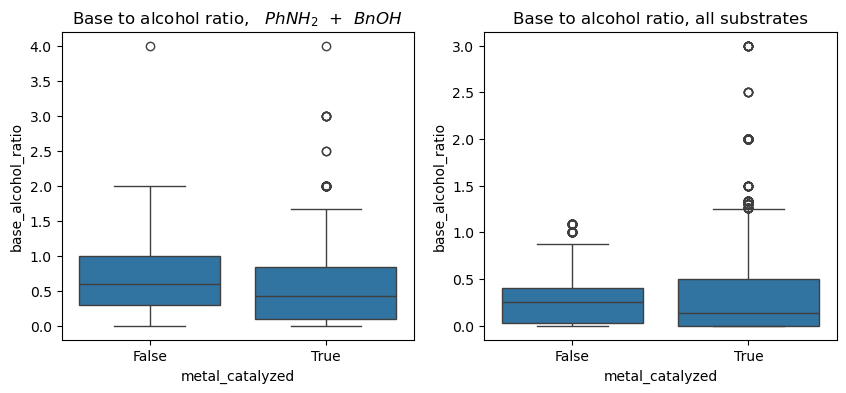

In [24]:
plt.figure(figsize=(10,4))
ax = plt.subplot(1, 2, 1) 
df_opt_succ['metal_catalyzed'] = ~df_opt_succ['metal'].isna()
sns.boxplot(data=df_opt_succ, y="base_alcohol_ratio", x="metal_catalyzed")
ax.set_title(f'Base to alcohol ratio,  {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}', fontsize = 12);

ax = plt.subplot(1, 2, 2) 
df_substr_hb_succ['metal_catalyzed'] = ~df_substr_hb_succ['metal'].isna()
sns.boxplot(data=df_substr_hb_succ, y="base_alcohol_ratio", x="metal_catalyzed")
          
ax.set_title('Base to alcohol ratio, all substrates', fontsize = 12);
plt.show()
df_substr_hb_succ.drop('metal_catalyzed', axis=1, inplace = True)
df_opt_succ.drop('metal_catalyzed', axis=1, inplace = True)


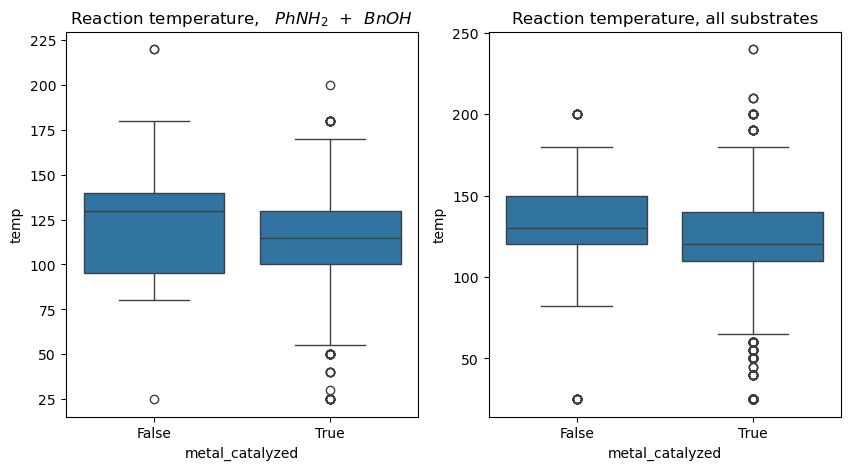

In [25]:
plt.figure(figsize=(10,5))
ax = plt.subplot(1, 2, 1) 
df_opt_succ['metal_catalyzed'] = ~df_opt_succ['metal'].isna()
sns.boxplot(data=df_opt_succ, y="temp", x="metal_catalyzed")
ax.set_title(f'Reaction temperature,  {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}', fontsize = 12);

ax = plt.subplot(1, 2, 2) 
df_substr_hb_succ['metal_catalyzed'] = ~df_substr_hb_succ['metal'].isna()
sns.boxplot(data=df_substr_hb_succ, y="temp", x="metal_catalyzed")
          
ax.set_title('Reaction temperature, all substrates', fontsize = 12);
plt.show()
df_substr_hb_succ.drop('metal_catalyzed', axis=1, inplace = True)
df_opt_succ.drop('metal_catalyzed', axis=1, inplace = True)

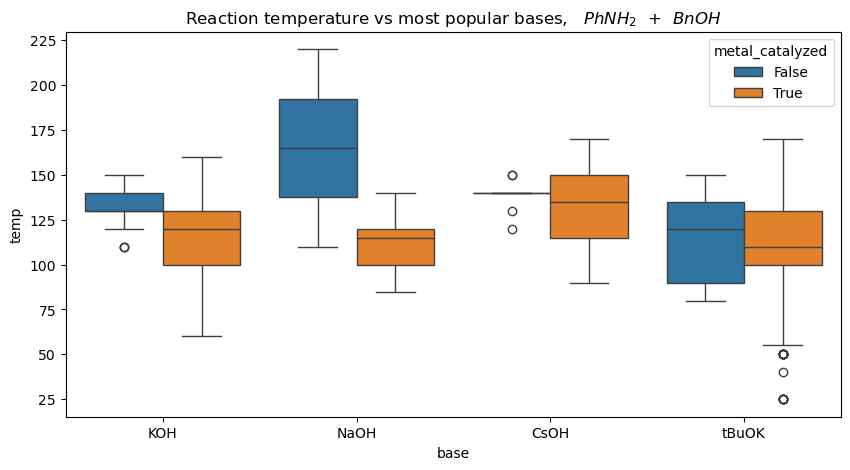

In [26]:
plt.figure(figsize=(10,5))
df_opt_succ['metal_catalyzed'] = ~df_opt_succ['metal'].isna()
sns.boxplot(data=df_opt_succ[df_opt_succ['base'].isin(['tBuOK', 'NaOH', 'CsOH', 'KOH', 'NaOH'])], y="temp", x="base", hue = 'metal_catalyzed')
plt.title(f'Reaction temperature vs most popular bases,  {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}', fontsize = 12);
df_opt_succ.drop('metal_catalyzed', axis=1, inplace = True)

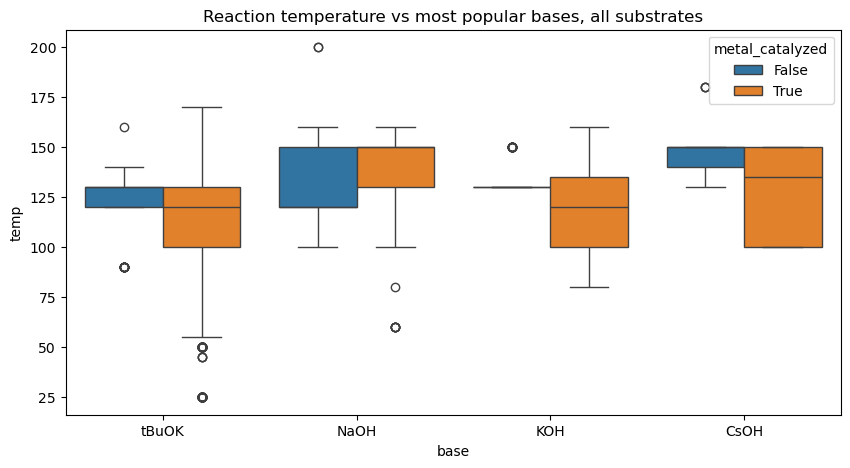

In [27]:
plt.figure(figsize=(10,5))
df_substr_hb_succ['metal_catalyzed'] = ~df_substr_hb_succ['metal'].isna()
sns.boxplot(data=df_substr_hb_succ[df_substr_hb_succ['base'].isin(['tBuOK', 'NaOH', 'CsOH', 'KOH', 'NaOH'])], y="temp", x="base", hue = 'metal_catalyzed')
plt.title(f'Reaction temperature vs most popular bases, all substrates', fontsize = 12);
df_substr_hb_succ.drop('metal_catalyzed', axis=1, inplace = True)

In [28]:
#add temp range
step = 30 #degrees centigrade
def get_temp_range(temp):
    num_range = int(temp/step)
    label = f'[{num_range*step },{(num_range+1)*step })'
    return num_range, label

df_opt['num_temp_range'], df_opt['label_temp_range'] = zip(*df_opt['temp'].apply(get_temp_range))

In [29]:
df_opt['label_temp_range'].value_counts().reset_index().loc[0. ]

label_temp_range    [120,150)
count                    1432
Name: 0, dtype: object

In [30]:
df_90_120 = df_opt[df_opt['label_temp_range'] == '[120,150)']
df_120_150 = df_opt[df_opt['label_temp_range'] == '[90,120)']
df_60_90 = df_opt[df_opt['label_temp_range'] == '[60,90)']


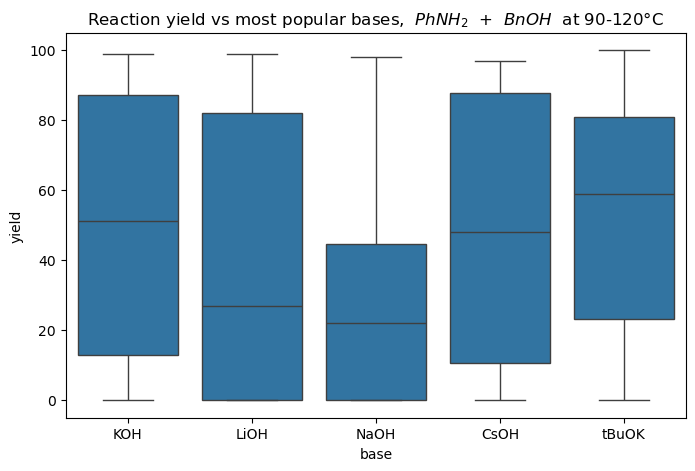

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_90_120[df_90_120['base'].isin(['tBuOK', 'NaOH', 'CsOH', 'KOH', 'NaOH', 'LiOH'])], y="yield", x="base")
plt.title(f'Reaction yield vs most popular bases, {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')} at 90-120°C', fontsize = 12);


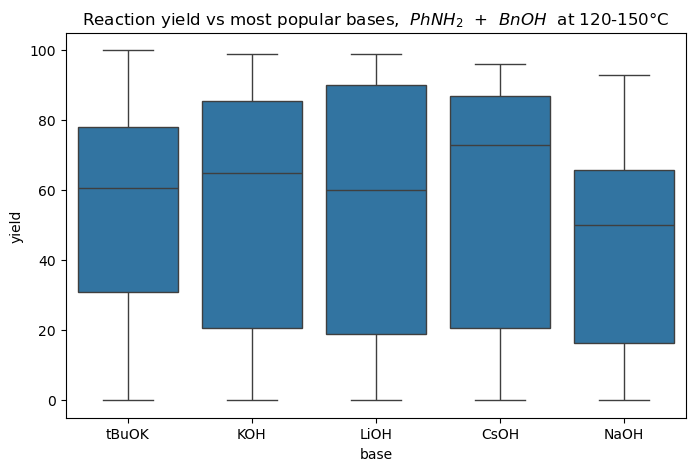

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_120_150[df_120_150['base'].isin(['tBuOK', 'NaOH', 'CsOH', 'KOH', 'NaOH', 'LiOH'])], y="yield", x="base")
plt.title(f'Reaction yield vs most popular bases, {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')} at 120-150°C', fontsize = 12);


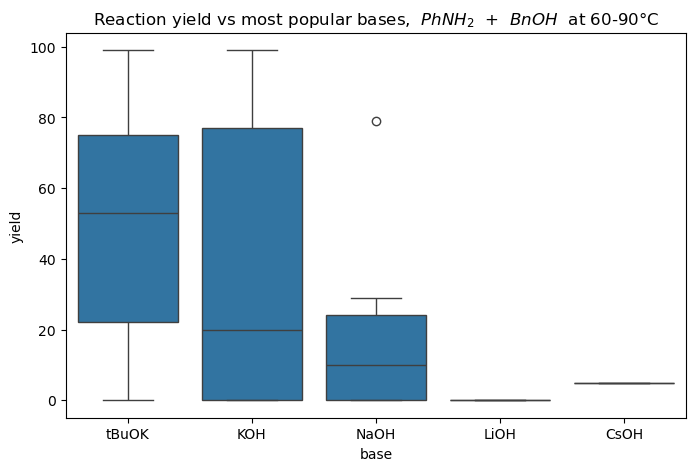

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_60_90[df_60_90['base'].isin(['tBuOK', 'NaOH', 'CsOH', 'KOH', 'NaOH', 'LiOH'])], y="yield", x="base")
plt.title(f'Reaction yield vs most popular bases, {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')} at 60-90°C', fontsize = 12);


## Analysys of the optimization data for PhNH<sub>2</sub> + BnOH reaction

In [34]:
# calculate bases success rate for this reaction
df_opt['success'] = df_opt['yield'] > 65 

bases_df = pd.crosstab(df_opt['base'], df_opt['success'])
bases_df['total'] = bases_df.apply(lambda x: x[True] + x[False], axis = 1)

org_bases = ['Et3N', 'DABCO', 'DBU', 'TBD', 'Pyridine', 'DMAP', 'DIPEA', 'TMEDA']
bases_df.loc['organic_base', True] = 0
for x in org_bases:
    bases_df.loc['organic_base', True] += bases_df.loc[x, True]
bases_df.loc['organic_base', False] = 0
for x in org_bases:
    bases_df.loc['organic_base', False] += bases_df.loc[x, False]    
bases_df.loc['organic_base', 'total'] = 0
for x in org_bases:
    bases_df.loc['organic_base', 'total'] += bases_df.loc[x, 'total'] 
bases_df = bases_df.drop(org_bases).sort_values(by = 'total', ascending = False).copy()
bases_df = bases_df[bases_df['total']>10].copy()
bases_df['true_fraction'] = bases_df[True]/bases_df['total']
bases_df['false_fraction'] = bases_df[False]/bases_df['total']
bases_df

success,False,True,total,true_fraction,false_fraction
base,,,,,
tBuOK,821.0000,614.0000,1435.0000,0.4279,0.5721
no base,463.0000,222.0000,685.0000,0.3241,0.6759
KOH,299.0000,218.0000,517.0000,0.4217,0.5783
K2CO3,107.0000,16.0000,123.0000,0.1301,0.8699
LiOH,71.0000,52.0000,123.0000,0.4228,0.5772
NaOH,69.0000,16.0000,85.0000,0.1882,0.8118
tBuONa,73.0000,11.0000,84.0000,0.1310,0.8690
Cs2CO3,57.0000,16.0000,73.0000,0.2192,0.7808
organic_base,49.0000,1.0000,50.0000,0.0200,0.9800


<Figure size 1000x500 with 0 Axes>

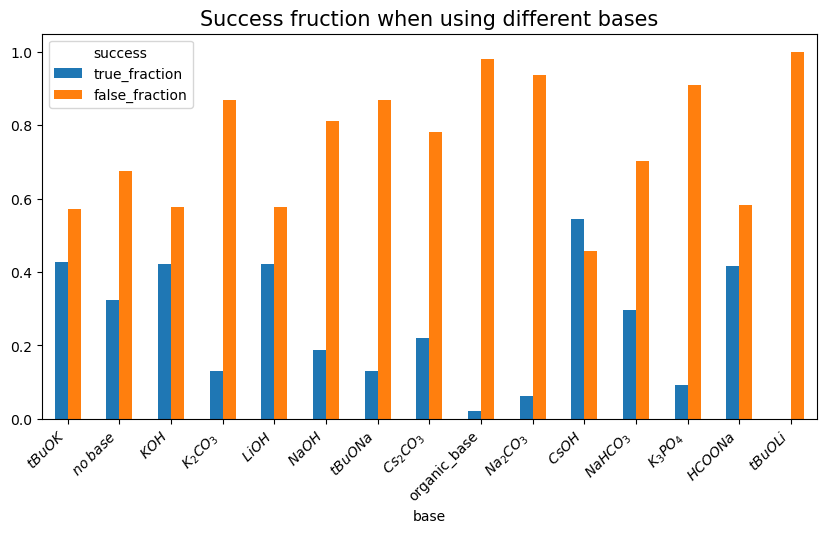

In [35]:
plt.figure(figsize = (10,5));
ax = bases_df[['true_fraction','false_fraction' ]].plot(kind='bar', figsize=(10, 5)) ;
ax.set_xticklabels([pf.to_chem(y) if y != 'organic_base' else y for y in bases_df.index], rotation=45, ha='right') ;
ax.set_title('Success fruction when using different bases', fontsize = 15);

One can see that tBuOK and CsOH are the most successful bases to check in BH amination

In [36]:
#add temp range
step = 10 #degrees centigrade
def get_temp_range(temp):
    num_range = int(temp/step)
    label = f'[{num_range*step },{(num_range+1)*step })'
    return num_range, label

df_opt['num_temp_range'], df_opt['label_temp_range'] = zip(*df_opt['temp'].apply(get_temp_range))

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 5 times are neglected


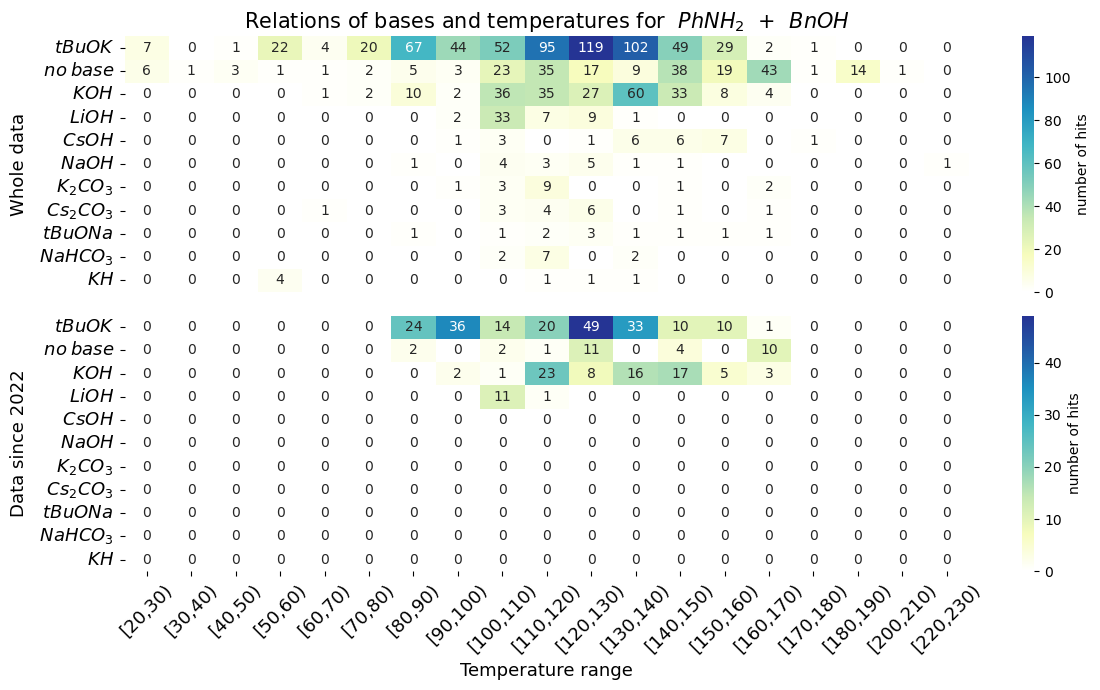

In [37]:
filter_val = 5
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')
pf.plot_diff_graph(    
    df_opt.loc[df_opt['success']], 
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (12, 7),
    xlabel = 'Temperature range',
    title = f'Relations of bases and temperatures for {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    # debug = True
    sort_vertical = True, 
    sort_horizontal = False
)


Number in the intersection shows the number of successful reactions in this conditions. Metals appeared less than 5 times are neglected


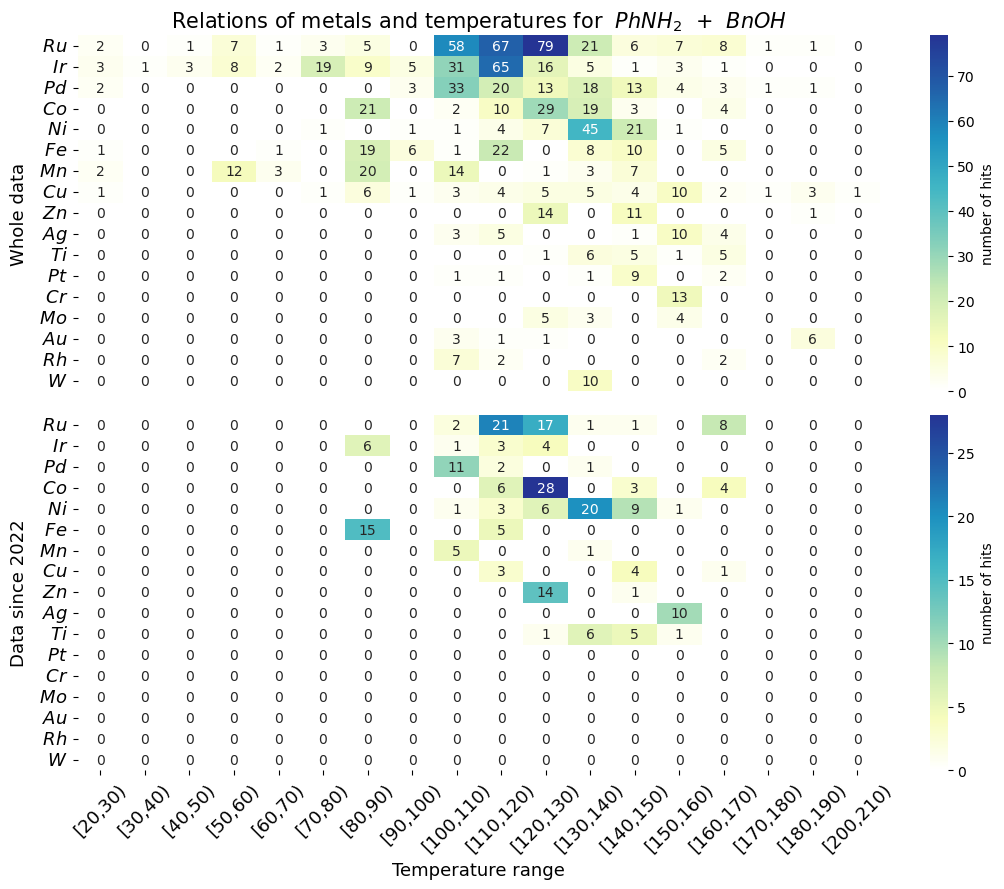

In [38]:
#relations of metals and temperatured for PhNH2 and BnOH reaction
filter_val = 5
print(f'Number in the intersection shows the number of successful reactions in this conditions. Metals appeared less than {filter_val } times are neglected')
pf.plot_diff_graph(    
    df_opt.loc[df_opt['success']], 
    'metal', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (11, 9),
    xlabel = 'Temperature range',
    title = f'Relations of metals and temperatures for {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    # debug = True
    sort_vertical = True, 
    sort_horizontal = False
)



In [39]:
mdf = df_opt['metal'].value_counts().reset_index()
print('The most popular metals by the number of hits are')
mdf[mdf['count'] > 100]

The most popular metals by the number of hits are


,metal,count
0,Ru,617
1,Ir,412
2,Pd,249
3,Co,247
4,Ni,235
5,Mn,177
6,Fe,166
7,Cu,137


Plot base to temperature relations for all these metals

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 5 times are neglected


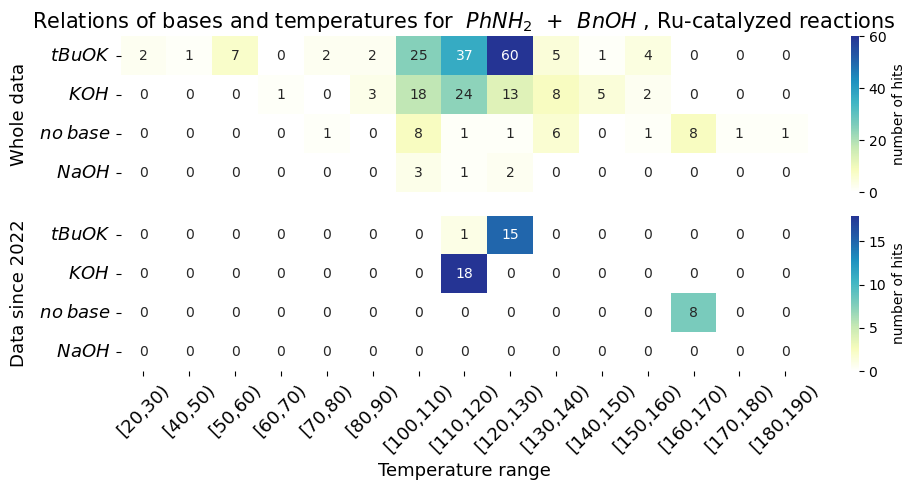

In [40]:
filter_val = 5
metal = 'Ru'
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')
pf.plot_diff_graph(    
    df_opt.loc[(df_opt['success']) & (df_opt['metal'] == metal)], 
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (10, 5),
    xlabel = 'Temperature range',
    title = f'Relations of bases and temperatures for {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}, {metal}-catalyzed reactions',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    # debug = True
    sort_vertical = True, 
    sort_horizontal = False
)

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 5 times are neglected


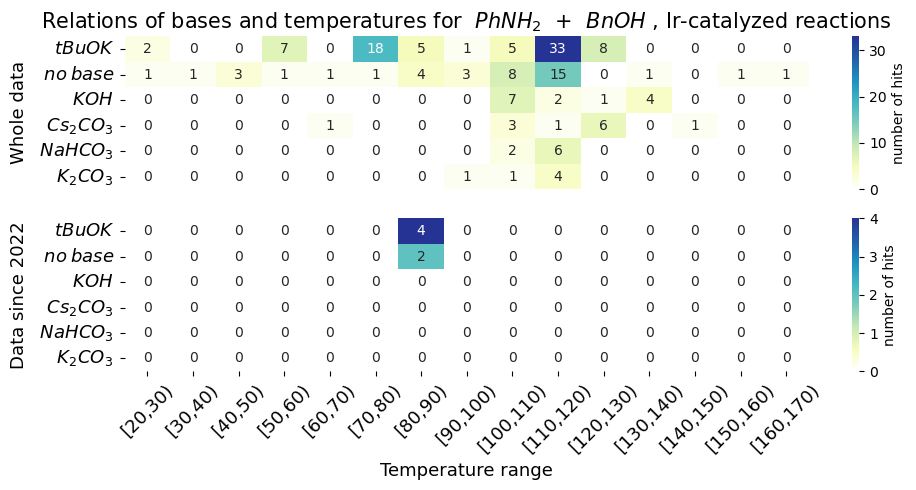

In [41]:
filter_val = 5
metal = 'Ir'
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')
pf.plot_diff_graph(    
    df_opt.loc[(df_opt['success']) & (df_opt['metal'] == metal)], 
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (10, 5),
    xlabel = 'Temperature range',
    title = f'Relations of bases and temperatures for {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}, {metal}-catalyzed reactions',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    # debug = True
    sort_vertical = True, 
    sort_horizontal = False
)

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 5 times are neglected


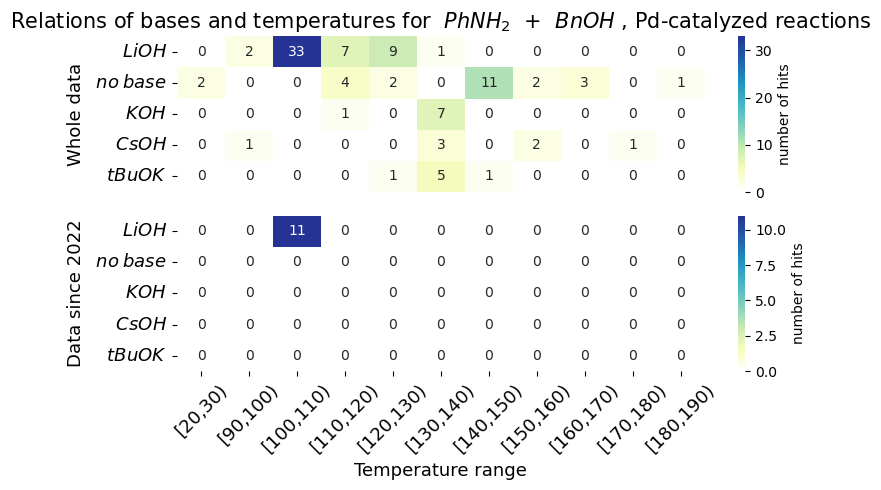

In [42]:
filter_val = 5
metal = 'Pd'
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')
pf.plot_diff_graph(    
    df_opt.loc[(df_opt['success']) & (df_opt['metal'] == metal)], 
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (8, 5),
    xlabel = 'Temperature range',
    title = f'Relations of bases and temperatures for {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}, {metal}-catalyzed reactions',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    # debug = True
    sort_vertical = True, 
    sort_horizontal = False
)

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 5 times are neglected


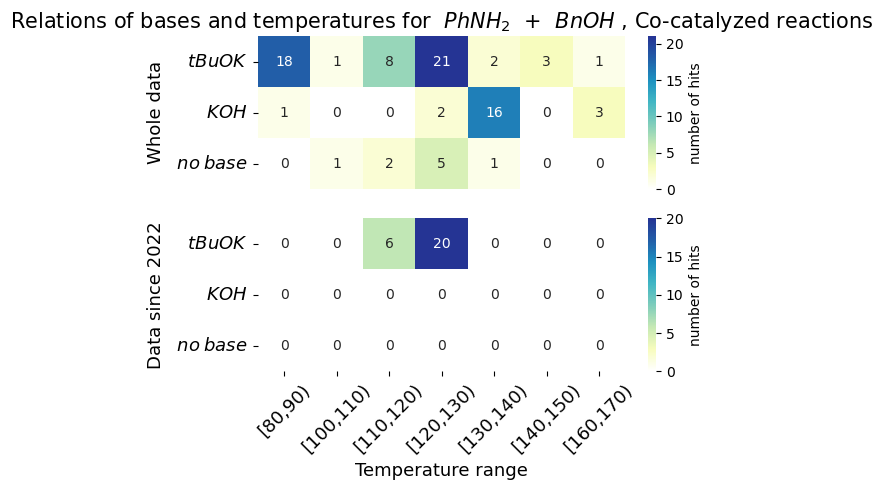

In [43]:
filter_val = 5
metal = 'Co'
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')
pf.plot_diff_graph(    
    df_opt.loc[(df_opt['success']) & (df_opt['metal'] == metal)], 
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (6, 5),
    xlabel = 'Temperature range',
    title = f'Relations of bases and temperatures for {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}, {metal}-catalyzed reactions',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    # debug = True
    sort_vertical = True, 
    sort_horizontal = False
)

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 1 times are neglected


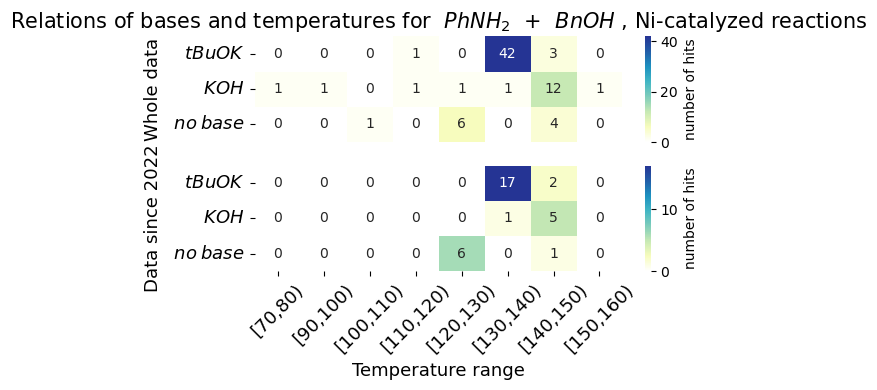

In [44]:
filter_val = 1
metal = 'Ni'
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')
pf.plot_diff_graph(    
    df_opt.loc[(df_opt['success']) & (df_opt['metal'] == metal)], 
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (6, 4),
    xlabel = 'Temperature range',
    title = f'Relations of bases and temperatures for {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}, {metal}-catalyzed reactions',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    # debug = True
    sort_vertical = True, 
    sort_horizontal = False
)

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 1 times are neglected


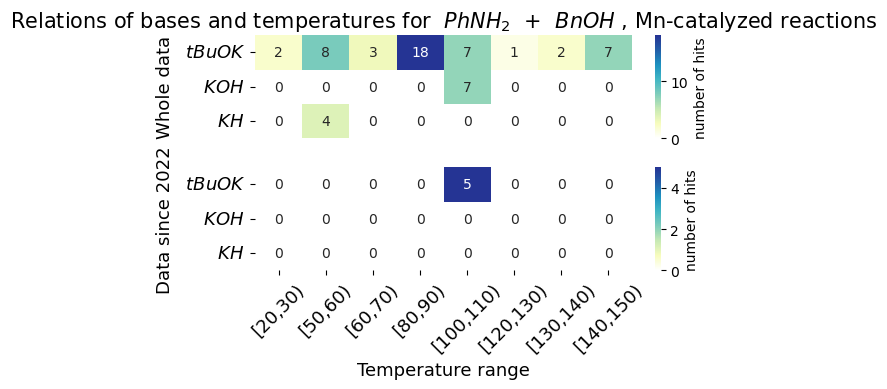

In [45]:
filter_val = 1
metal = 'Mn'
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')
pf.plot_diff_graph(    
    df_opt.loc[(df_opt['success']) & (df_opt['metal'] == metal)], 
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (6, 4),
    xlabel = 'Temperature range',
    title = f'Relations of bases and temperatures for {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}, {metal}-catalyzed reactions',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    # debug = True
    sort_vertical = True, 
    sort_horizontal = False
)

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 1 times are neglected


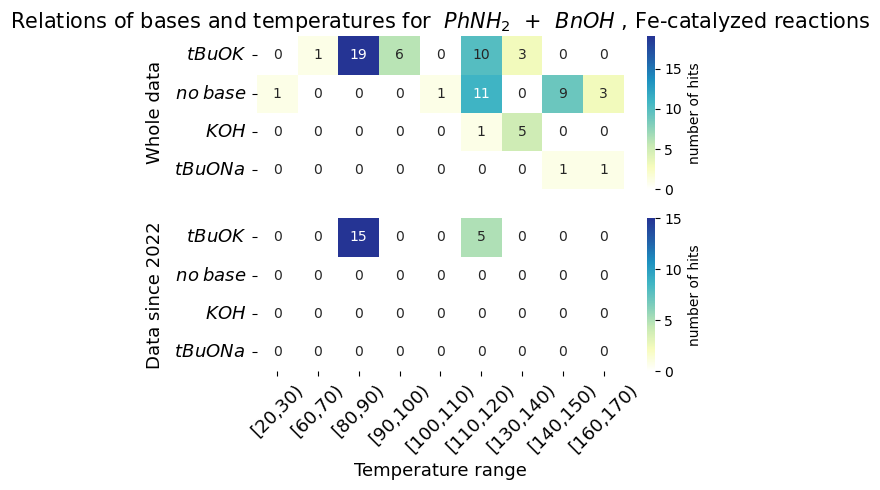

In [46]:
filter_val = 1
metal = 'Fe'
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')
pf.plot_diff_graph(    
    df_opt.loc[(df_opt['success']) & (df_opt['metal'] == metal)], 
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (6, 5),
    xlabel = 'Temperature range',
    title = f'Relations of bases and temperatures for {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}, {metal}-catalyzed reactions',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    # debug = True
    sort_vertical = True, 
    sort_horizontal = False
)

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 1 times are neglected


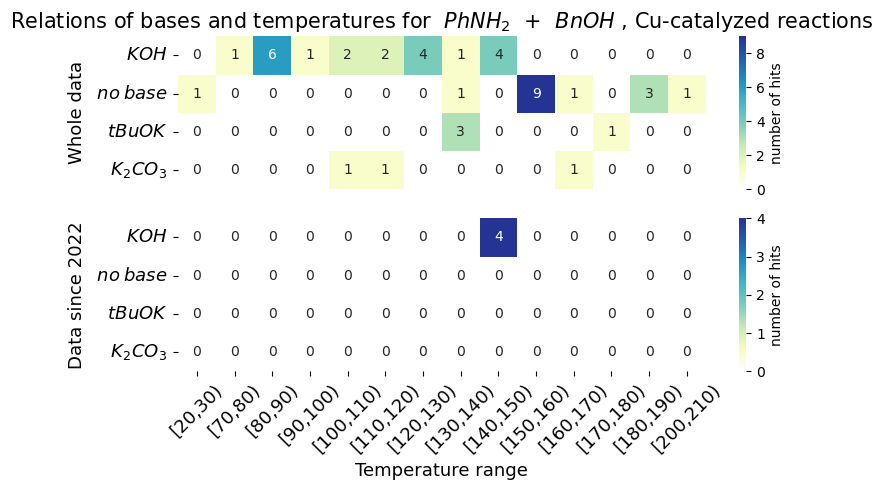

In [47]:
filter_val = 1
metal = 'Cu'
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')
pf.plot_diff_graph(    
    df_opt.loc[(df_opt['success']) & (df_opt['metal'] == metal)], 
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (8, 5),
    xlabel = 'Temperature range',
    title = f'Relations of bases and temperatures for {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}, {metal}-catalyzed reactions',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    # debug = True
    sort_vertical = True, 
    sort_horizontal = False
)

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 1 times are neglected


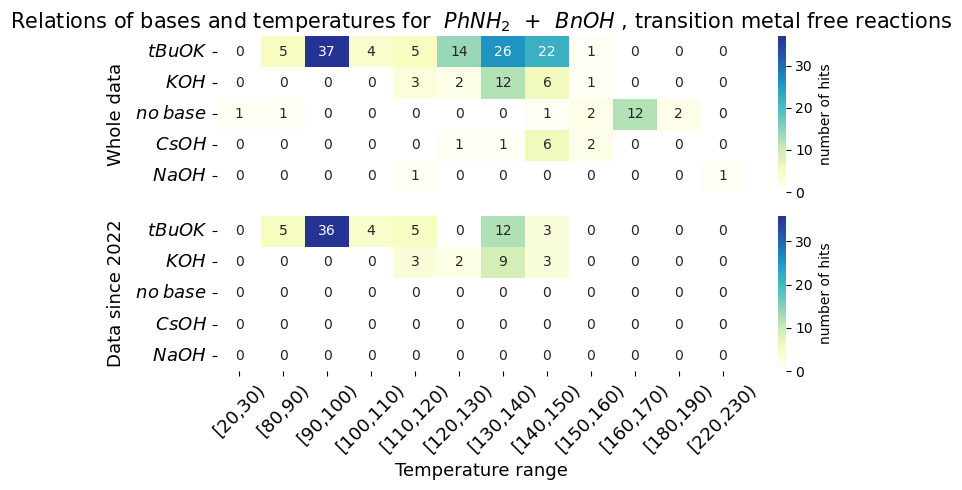

In [48]:
filter_val = 1
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')
pf.plot_diff_graph(    
    df_opt.loc[(df_opt['yield']>65) & (df_opt['metal'].isna())], 
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (8, 5),
    xlabel = 'Temperature range',
    title = f'Relations of bases and temperatures for {pf.to_chem('PhNH2')} + {pf.to_chem('BnOH')}, transition metal free reactions',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    # debug = True
    sort_vertical = True, 
    sort_horizontal = False
)

In [49]:
pf.solvent_diel_const #This is a dict for the solvent dielectric constants

{'PhMe': 2.4,
 'dioxane': 2.3,
 'p-xylene': 2.3,
 'THF': 7.5,
 'diglyme': 7.3,
 'H2O': 78.2,
 'mesitylene': 2.4,
 'MeCN': 36.0,
 'trifluoroethanol': 26.7,
 'DMF': 37.1,
 'hexane': 1.9,
 'o-xylene': 2.6,
 'DMSO': 46.7,
 'DCM': 9.0,
 'octane': 2.0,
 'tAmOH': 15.8,
 'PhCF3': 9.1,
 'DME': 7.2,
 'anisole': 4.5,
 'DCE': 10.7,
 'CyH': 2.0,
 'benzene': 2.4,
 'PhCl': 5.7,
 'EtOH': 24.5,
 'm-xylene': 2.4,
 'xylene': 2.4,
 'MeOH': 33.6,
 'DMA': 38.3,
 'EtOAc': 6.0,
 'dichlorobenzene': 10.4,
 'PhF': 5.6,
 'NMP': 32.2,
 'iPrOH': 18.2,
 'tBuOH': 9.3,
 'heptane': 1.4,
 'Et2O': 4.4,
 'CHCl3': 4.9,
 'pyridine': 13.2,
 'ethylene diamine': 16.0,
 'Et3N': 2.5,
 'cymene': 2.3,
 'PhtBu': 6.4,
 'PhNO2': 36.1,
 'morpholine': 7.7,
 'nBuOH': 17.8,
 'ethylene glycol': 37.0,
 'AcOH': 6.2,
 'MeOtBu': 4.5,
 'propylene carbonate': 62.9,
 'MeNO2': 36.2,
 'BuOAc': 5.0,
 'HFIP': 16.7,
 'AmOH': 15.8}

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


Relation of success fraction to the solvent dielectric constant. Solvents used less than 5 times are neglected. Success fraction is number of successful reactions of PhNH2 with BnOH in this solvent divided by the total number of reactions of these substrates in this solvent.


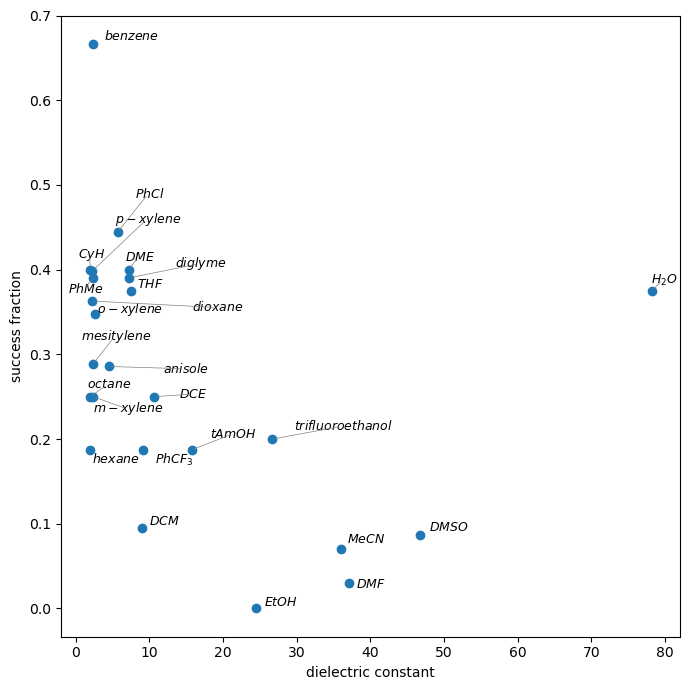

In [50]:
solv_df = pd.crosstab(df_opt['solvent'], df_opt['success'])
solv_df['total'] = solv_df.apply(lambda x: x[True] + x[False], axis = 1)
solv_df['diel_const'] = solv_df.index.map(pf.solvent_diel_const)

solv_df = solv_df.sort_values(by = 'total', ascending = False).reset_index()
solv_df_plot = solv_df[solv_df['total'] > 5].dropna(subset = 'diel_const')
plt.figure(figsize = (7,7))
plt.plot(solv_df_plot['diel_const'],solv_df_plot[True]/solv_df_plot['total'], 'o')
plt.xlabel('dielectric constant')
plt.ylabel('success fraction')

texts = []
for _, row in solv_df_plot.iterrows():
    texts.append(plt.text(row['diel_const'], 
                         row[True]/row['total'], 
                         pf.to_chem(row['solvent']),
                         fontsize=9))

# Автоматически корректируем положение подписей
adjust_text(texts, 
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
            expand_points=(1.2, 1.2),  
            expand_text=(1.2, 1.2),    
            force_text=(0.5, 0.8),     
            force_points=(0.2, 0.5))   

plt.tight_layout()
print('Relation of success fraction to the solvent dielectric constant. Solvents used less than 5 times are neglected. Success fraction is number of successful reactions of PhNH2 with BnOH in this solvent divided by the total number of reactions of these substrates in this solvent.')
plt.show()

### Creating consolidated tables for metal leaders for PhNH<sub>2</sub> with BnOH reaction

In [51]:
metals = list(set(df_opt['metal'].to_list()))
metals = [x for x in metals if (x != '0' and x is not None and x == x)]
metal_leaders = []
for metal in metals:
    metal_df = df_opt[df_opt['metal'] == metal]
    metal_df.dropna(subset = 'TON', inplace = True)
    metal_df = metal_df[metal_df['TON']<100000000000]
    record = {'metal': metal}
    record['num_papers'] =  len(set(metal_df['doi'].to_list()))
    # maximal TON among all (TONmax(1)/T,°C/base/catalyst typea/atmosphere)
    best = metal_df.sort_values(by = 'TON', ascending = False).to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = None
            print('ERROR, no data on TON')
        record['max_ton'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['year']}/{best['comment']})'
    else:
        record['max_ton'] = 'no data'
    # maximal TON among the processes with preparative yields (TONmax(2)/T,°C/base/catalyst typea/atmosphere)
    best = metal_df[metal_df['yield']>65].sort_values(by = 'TON', ascending = False).to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = None
            print('ERROR, no data on TON')
        record['max_ton_prep'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['year']}/{best['comment']})'
    else:
        record['max_ton_prep'] = 'no data'
    
    #the lowest temperature in the presence of base (TON/Tmin(1),°C/base/catalyst typea/atmosphere)
    best = metal_df[metal_df['yield']>65].sort_values(by = 'temp').to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = None
            print('ERROR, no data on TON')
        record['min_temp'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['year']}/{best['comment']})'
    else:
        record['min_temp'] = 'no data'
    #the highest TON in the absence of base (TONmax(3)/T,°C/base/catalyst typea/atmosphere)
    best = metal_df[metal_df['base']=='no base'].sort_values(by = 'TON', ascending = False).to_dict('records')
    if len(best):
        best = best[0]  
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['max_ton_no_base'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['year']}/{best['comment']})'
    else:
        record['max_ton_no_base'] = 'no data'
        
    #The lowest temperature in the absence of base (TON/Tmin(2),°C/base/catalyst typea/atmosphere)
    best = metal_df.loc[metal_df['base']=='no base'].loc[metal_df['yield']>65].sort_values(by = 'temp').to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['min_temp_no_base'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['year']}/{best['comment']})'
    else:
        record['min_temp_no_base'] = 'no data'
    bases = metal_df[metal_df['yield']>65]['base'].value_counts().index.to_list()
    if len(bases) > 1:
        record['most_popular_working_bases']= bases[0:2]
    else:
        record['most_popular_working_bases']= bases
    metal_leaders.append(record)

metal_leaders = sorted(metal_leaders, key = lambda x: x['num_papers'], reverse = True)
metal_leaders = [x for x in metal_leaders if x['num_papers'] > 0]

In [52]:
document = Document()
data = metal_leaders
        
sections = document.sections
for section in sections:
    section.orientation = WD_ORIENT.LANDSCAPE

p = document.add_paragraph() 
run = p.add_run('Best catalysts by metals for PhNH2 + BnOH process')
run.font.size = Pt(14)
paragraph_format = p.paragraph_format
paragraph_format.alignment = WD_ALIGN_PARAGRAPH.CENTER
p = document.add_paragraph('Data stracture in all cells: (TONmax/T,°C/base/catalyst/atmosphere/doi/year/comment)') 

col_names = ['Metal', 'Number of papers', 
            'Maximal TON among all ', 
             'Maximal TON among the processes with preparative yields >65%',
                'The lowest temperature among all with preparative yields >65%',
             'The highest TON in the absence of base',
             'The lowest temperature in the absence of base with preparative yields >65%', 
            'most popular working bases']
table = document.add_table(rows= len(data) +1 , cols=len(col_names))
row = table.rows[0]
for idx, col_name in enumerate(col_names):
    
    for p in row.cells[idx].iter_inner_content():
        break
    run = p.add_run(col_name)
    run.bold = True
    
for row_idx, item in enumerate(data):
    row = table.rows[row_idx+1] #так как нулевой ряд - заголовок
    row.cells[0].text = item['metal']
    row.cells[1].text = str(item['num_papers'])
    row.cells[2].text = str(item['max_ton'])
    row.cells[3].text = str(item['max_ton_prep'])
    row.cells[4].text = str(item['min_temp'])
    row.cells[5].text = str(item['max_ton_no_base'])
    row.cells[6].text = str(item['min_temp_no_base'])
    row.cells[7].text = str(item['most_popular_working_bases'])
    

document.save(r'doc_tables\best_cats_PhNH2_BnOH.docx')

In [53]:
pd.DataFrame(metal_leaders)

,metal,num_papers,max_ton,max_ton_prep,min_temp,max_ton_no_base,min_temp_no_base,most_popular_working_bases
0,Ru,66,"(42840/110.0°C/tBuOK/Ru(1,10-phenanthroline)Py(PPh3)2(PF6)/inert/10.1002/adsc.201701117/2017/0)",(12833/170.0°C/no base/Ru@Beta/inert/https://doi.org/10.1016/j.cej.2024.152457/2024/0),(76/25.0°C/tBuOK/[Ru(COD)Cl2]n/inert/10.1016/j.catcom.2017.03.007/2017/0),(12833/170.0°C/no base/Ru@Beta/inert/https://doi.org/10.1016/j.cej.2024.152457/2024/0),(83/70.0°C/no base/(p-cymene)Ru(L1)Cl/oxygen/10.1021/acs.orglett.1c02968/2021/0),"[tBuOK, KOH]"
1,Ir,59,(1840/70.0°C/tBuOK/(Ir(cod)Ome)2/inert/10.1002/chem.201402952/2014/0),(920/70.0°C/tBuOK/Ir*PNP complex/inert/10.1002/chem.201001871/2010/0),(192/25.0°C/tBuOK/IrNHC/inert/10.1039/c3cc42669f/2013/0),(890/78.0°C/no base/(2EtNHC)IrCp*Cl2/inert/10.1002/ejoc.202301105/2024/0),(50/25.0°C/no base/(2EtNHC)IrCp*Cl2/inert/10.1002/ejoc.202301105/2024/0),"[tBuOK, no base]"
2,Pd,27,(44500/130.0°C/LiOH/Pd2((AcO)pirazoleAr3)2/inert/10.1016/j.tet.2017.03.001/2017/0),(44500/130.0°C/LiOH/Pd2((AcO)pirazoleAr3)2/inert/10.1016/j.tet.2017.03.001/2017/0),"(31/25.0°C/no base/Pd0,3/TiO2/inert/10.1021/cs300756f/2013/irradiation)",(553/160.0°C/no base/Pd/Fe2O3/inert/10.1016/j.tetlet.2011.01.059/2011/0),"(31/25.0°C/no base/Pd0,3/TiO2/inert/10.1021/cs300756f/2013/irradiation)","[LiOH, no base]"
3,Co,20,(3256/140.0°C/tBuOK/Co1-N3P1/inert/10.1021/jacs.4c07197/2024/0),(3256/140.0°C/tBuOK/Co1-N3P1/inert/10.1021/jacs.4c07197/2024/0),(84/80.0°C/tBuOK/Co-PNP-pincer/inert/10.1021/acs.orglett.6b01647/2016/0),(167/25.0°C/no base/Co/TiO2/inert/10.1016/j.apcatb.2022.121264/2022/14W blue LED),(33/100.0°C/no base/Co-PNP-pincer/inert/10.1021/acs.orglett.5b03461/2015/0),"[tBuOK, KOH]"
4,Fe,19,(313/135.0°C/KOH/Fe20-SA@NSC/inert/10.1039/d1ta07673f/2021/0),(313/135.0°C/KOH/Fe20-SA@NSC/inert/10.1039/d1ta07673f/2021/0),(50/25.0°C/no base/Fe/TiO2/inert/10.1016/j.apcatb.2022.121264/2022/14W blue LED),(50/25.0°C/no base/Fe/TiO2/inert/10.1016/j.apcatb.2022.121264/2022/14W blue LED),(50/25.0°C/no base/Fe/TiO2/inert/10.1016/j.apcatb.2022.121264/2022/14W blue LED),"[tBuOK, no base]"
5,Cu,19,(367/100.0°C/KOH/Cu/Magnetitt/oxygen/10.1039/c3gc40818c/2013/0),(367/100.0°C/KOH/Cu/Magnetitt/oxygen/10.1039/c3gc40818c/2013/0),(70/25.0°C/no base/[CuNNO(OAc)]2/oxygen/10.1039/d2dt01771g/2022/12 W White LEDs),(176/160.0°C/no base/Cu/CeO2-P/inert/10.1016/j.jcat.2023.01.020/2023/0),(70/25.0°C/no base/[CuNNO(OAc)]2/oxygen/10.1039/d2dt01771g/2022/12 W White LEDs),"[KOH, no base]"
6,Ni,18,(17500/200.0°C/tBuONa/NiNNN/inert/10.1021/acs.organomet.0c00233/2020/0),(1720/130.0°C/tBuOK/NiN4Br/inert/10.1039/d2gc02206k/2022/0),(26/100.0°C/no base/Ni/Ru@SBA/inert/10.1021/acssuschemeng.2c01092/2022/0),(99/144.0°C/no base/Ni/θ-Al2O3/inert/10.1021/cs4001267/2013/0),(26/100.0°C/no base/Ni/Ru@SBA/inert/10.1021/acssuschemeng.2c01092/2022/0),"[tBuOK, KOH]"
7,Mn,12,(550/50.0°C/KH/Mn(CO)5Br/inert/10.1021/acs.orglett.9b00832/2019/0),(277/50.0°C/KH/Mn(CO)5Br/inert/10.1021/acs.orglett.9b00832/2019/0),(61/25.0°C/tBuOK/Mn(CO)3(NHC)2/inert/10.1039/c9cc02989c/2019/0),(10/100.0°C/no base/Mn(NHC1)2(CO)3Br/inert/10.1021/acs.organomet.3c00046/2023/0),no data,"[tBuOK, KH]"
8,Au,10,(11566/180.0°C/no base/Au/TiO2-VS/inert/10.1002/chem.201001848/2010/0),(11566/180.0°C/no base/Au/TiO2-VS/inert/10.1002/chem.201001848/2010/0),(8/100.0°C/tBuOK/Ph3PAuCl/inert/10.1016/j.tet.2014.10.007/2014/0),(11566/180.0°C/no base/Au/TiO2-VS/inert/10.1002/chem.201001848/2010/0),(20/110.0°C/no base/Au/ZrO2/inert/10.1016/j.apcata.2011.11.017/2011/0),"[no base, tBuOK]"
9,Rh,9,(980/100.0°C/tBuOK/Rh(I)(COD)(NHC)triazoleC6H5/CB/oxygen/10.1021/acs.inorgchem.7b02586/2017/0),(196/100.0°C/no base/Cp*-S-Rh-N-anthracene-Cl/inert/10.1021/acs.organomet.8b00908/2019/0),(196/100.0°C/no base/Cp*-S-Rh-N-anthracene-Cl/inert/10.1021/acs.organomet.8b00908/2019/0),(196/100.0°C/no base/Cp*-S-Rh-N-anthracene-Cl/inert/10.1021/acs.organomet.8b00908/2019/0),(196/100.0°C/no base/Cp*-S-Rh-N-anthracene-Cl/inert/10.1021/acs.organom

## Analysis of trends for substrates

In [54]:
# unificattion of the spelling
df_substr_hb['nucleophile'] = df_substr_hb['amine_type'].map({
    'Aromatic': 'aromatic',  
    'Aliphatic': 'aliphatic',
    'Hetaromatic': 'heteroaromatic',
    'Sulfonamide': 'amide', 
    'Ammonia': 'aliphatic',
    'Amide': 'amide',
    'Alk2NH': 'aliphatic',
    'HetAromatic': 'heteroaromatic',
    'amide': 'amide',
    'NH4OAc': 'aliphatic',
    'Sulfinamide': 'amide',
    'SulfonamideK': 'amide',
    'ArAlkNH': 'aromatic',
    'Ph2NH': 'aromatic',
    'NH4BF4': 'aliphatic',
    'HCOONH4':  'aliphatic'    
})
df_substr_hb['alc_type'] = df_substr_hb['alcohol_type'].map({'BnOH': 'ArCH2OH', 'AlkCH2OH': 'AlkCH2OH', 'ArCH2OH': 'ArCH2OH', 'MeOH': 'MeOH', 'Alk2CHOH': 'Alk2CHOH', 'AlkArCHOH': 'AlkArCHOH', 'Bn2OH': 'Ar2CHOH',
       'HetBnOH': 'Ar2CHOH', 'AllOH': 'ArCH2OH', 'AlkEWGCHOH': 'Alk2CHOH', 'FcOH':  'ArCH2OH', 'bnOH':  'ArCH2OH', 'ArEWGCHOH':  'ArCH2OH',
       'EWGCH2OH':  'ArCH2OH', 'BnOh':  'ArCH2OH'})

In [55]:
df_substr_hb['nucleophile'].value_counts()

nucleophile
aromatic          5254
aliphatic         1608
heteroaromatic    1110
amide              607
Name: count, dtype: int64

In [56]:
# MeOH will be in a separate analytics
df_substr_hb = df_substr_hb[df_substr_hb['alcohol_type']!='MeOH'].copy()

In [57]:
df_substr_hb['alcohol_type'].value_counts()

alcohol_type
BnOH          5102
AlkCH2OH      1445
ArCH2OH        613
Alk2CHOH       424
AlkArCHOH      245
Bn2OH          105
HetBnOH         67
AllOH           49
AlkEWGCHOH      11
FcOH            10
ArEWGCHOH        6
EWGCH2OH         4
Name: count, dtype: int64

In [58]:
df_substr_hb.reset_index(drop = True, inplace = True)
df_substr_hb['success'] = df_substr_hb['yield'].apply(lambda x: x>65)

In [59]:
df_substr_hb['success'].value_counts()

success
True     6452
False    1629
Name: count, dtype: int64

In [60]:
df_substr_hb.dropna(subset = 'temp', inplace = True)

In [61]:
#add temp range
step = 10 #degrees centigrade
def get_temp_range(temp):
    num_range = int(temp/step)
    label = f'[{num_range*step},{(num_range+1)*step})'
    return num_range, label

df_substr_hb['num_temp_range'], df_substr_hb['label_temp_range'] = zip(*df_substr_hb['temp'].apply(get_temp_range))

In [62]:
df_substr_hb['metal'] = df_substr_hb['metal'].fillna('no metal')

### Amides

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 5 times are neglected


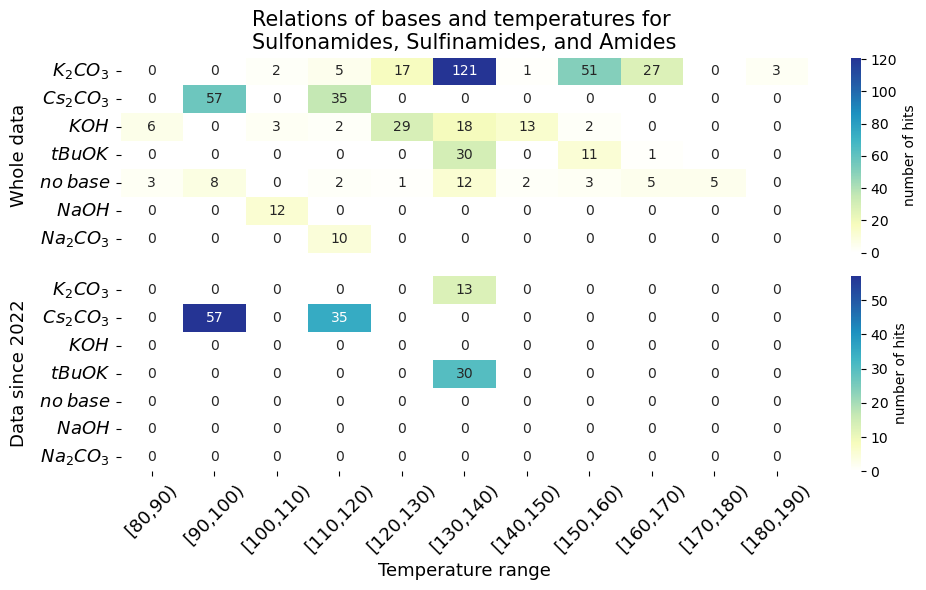

In [63]:
filter_val = 5
pf.plot_diff_graph(    
    df_substr_hb.loc[(df_substr_hb['success']) & (df_substr_hb['nucleophile']=='amide')],  
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (10, 6),
    xlabel = 'Temperature range',
    title = 'Relations of bases and temperatures for \nSulfonamides, Sulfinamides, and Amides',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 5 times are neglected


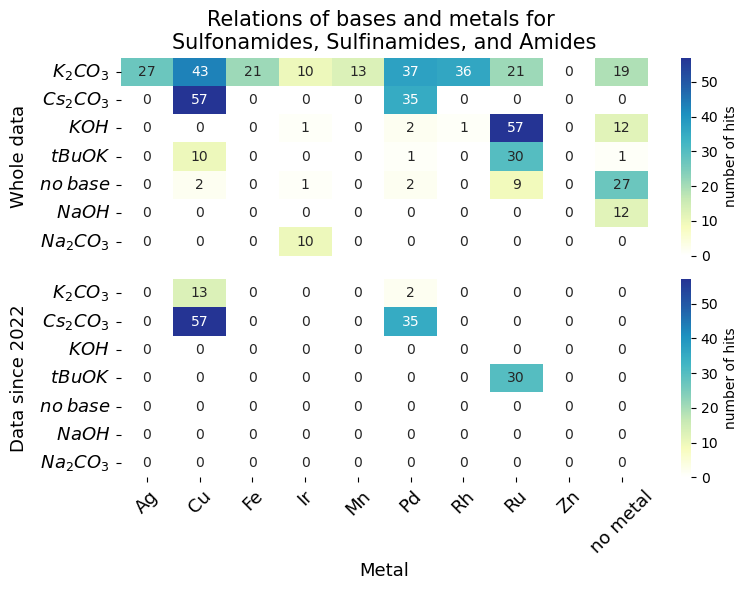

In [64]:
filter_val = 5
pf.plot_diff_graph(    
    df_substr_hb.loc[(df_substr_hb['success']) & (df_substr_hb['nucleophile']=='amide')], 
    'base', 
    'metal',
    filter_val = filter_val,
    figsize = (8, 6),
    xlabel = 'Metal',
    title = 'Relations of bases and metals for \nSulfonamides, Sulfinamides, and Amides',
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


### Heteroaromatic amines

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 5 times are neglected


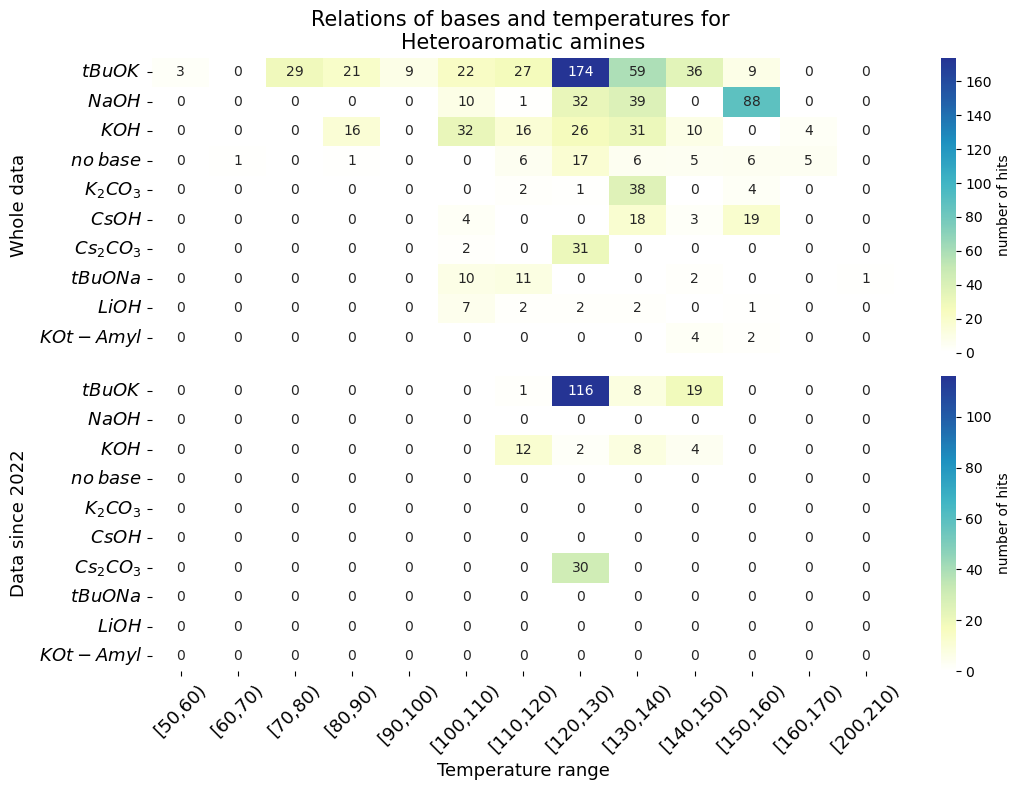

In [65]:
filter_val = 5
pf.plot_diff_graph(    
    df_substr_hb.loc[(df_substr_hb['success']) & (df_substr_hb['nucleophile']=='heteroaromatic')],  
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (11, 8),
    xlabel = 'Temperature range',
    title = 'Relations of bases and temperatures for \nHeteroaromatic amines',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 5 times are neglected


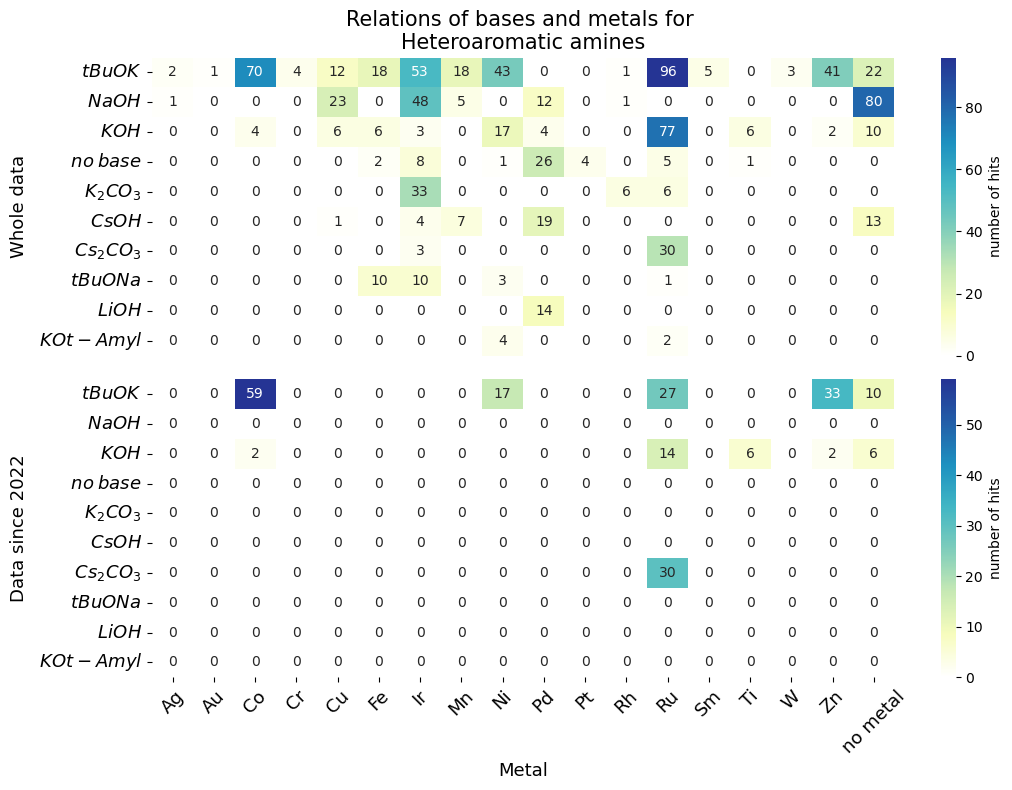

In [66]:
filter_val = 5
pf.plot_diff_graph(    
    df_substr_hb.loc[(df_substr_hb['success']) & (df_substr_hb['nucleophile']=='heteroaromatic')], 
    'base', 
    'metal',
    filter_val = filter_val,
    figsize = (11, 8),
    xlabel = 'Metal',
    title = 'Relations of bases and metals for \nHeteroaromatic amines',
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


### Aromatic amines

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 5 times are neglected


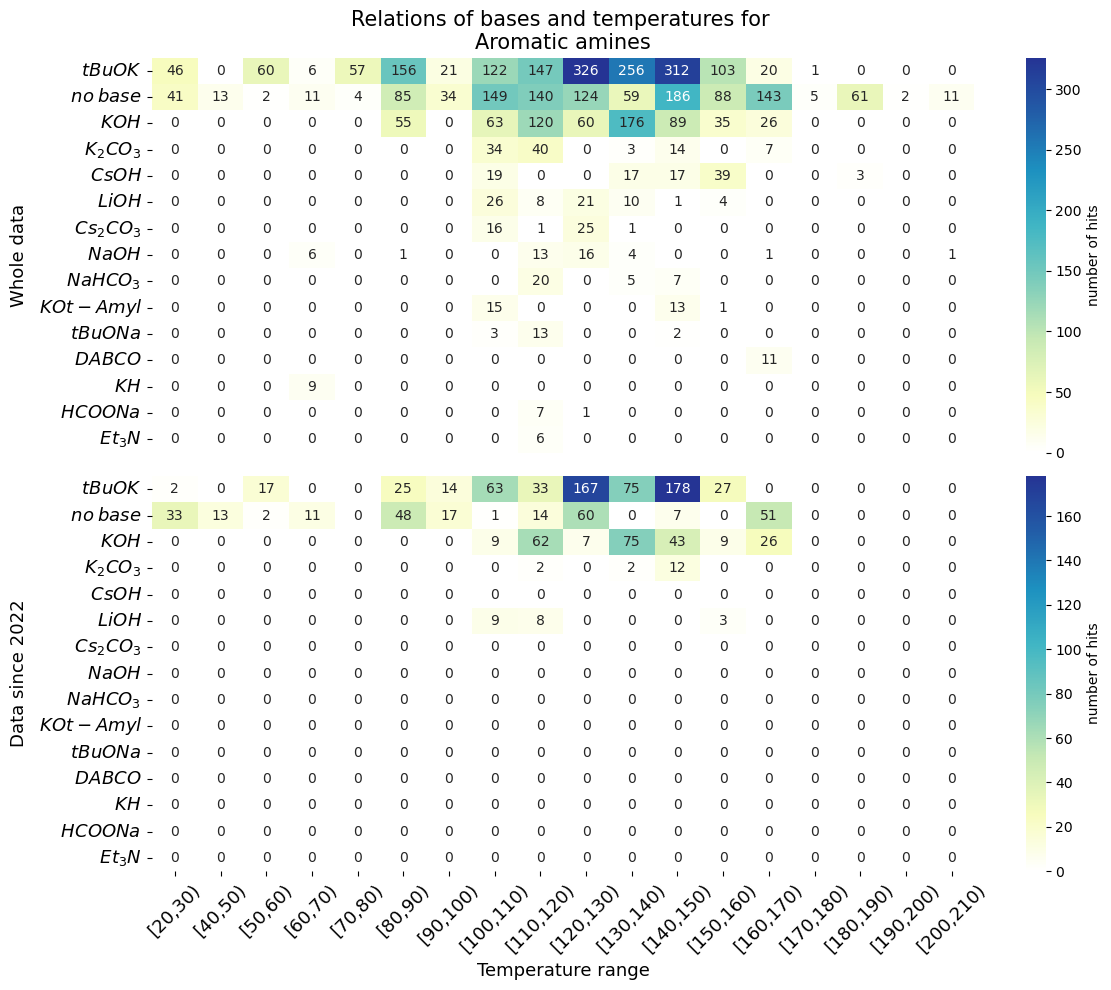

In [67]:
filter_val = 5
pf.plot_diff_graph(    
    df_substr_hb.loc[(df_substr_hb['success']) & (df_substr_hb['nucleophile']=='aromatic')],  
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (12, 10),
    xlabel = 'Temperature range',
    title = 'Relations of bases and temperatures for \nAromatic amines',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 5 times are neglected


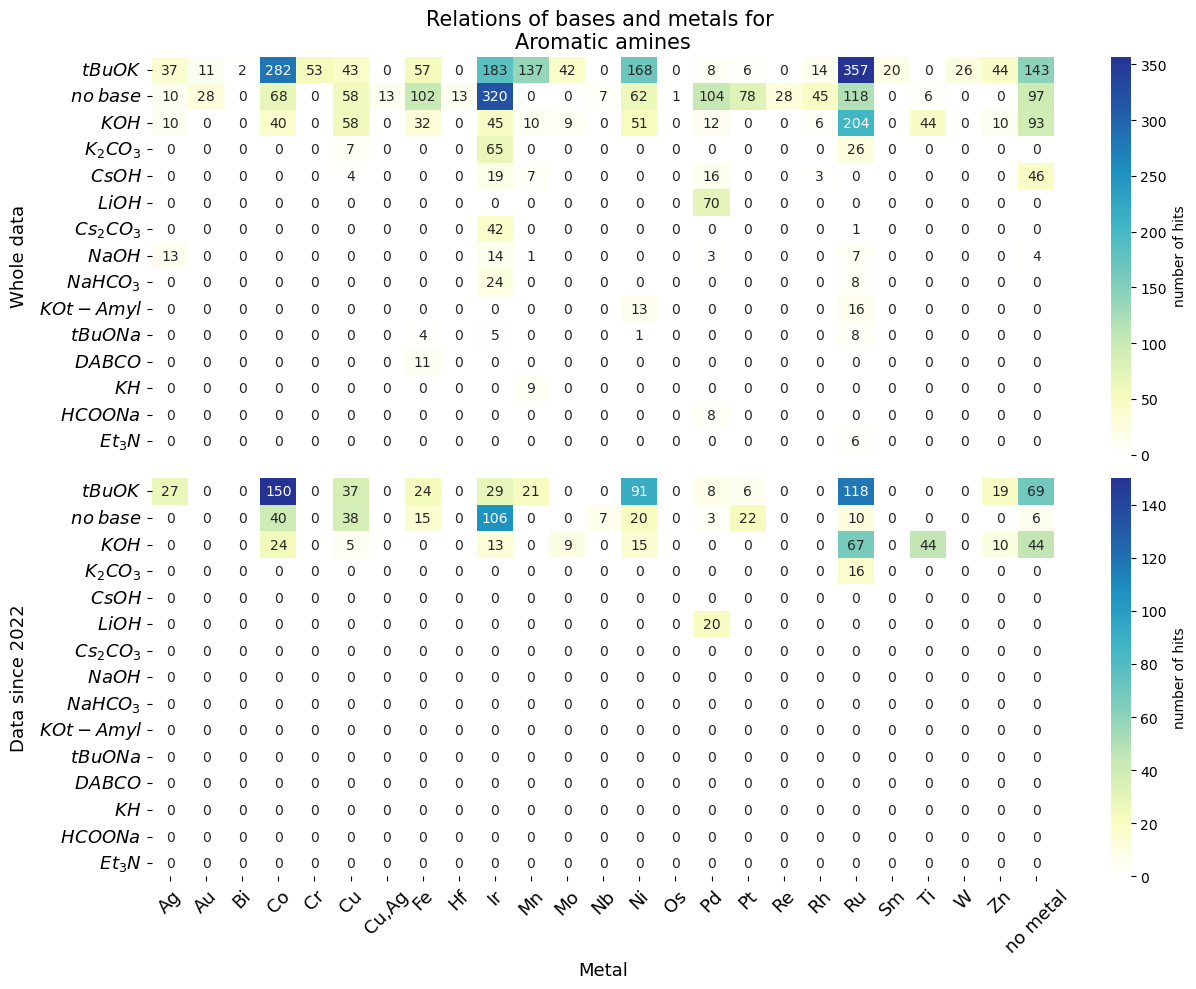

In [68]:
filter_val = 5
pf.plot_diff_graph(    
    df_substr_hb.loc[(df_substr_hb['success']) & (df_substr_hb['nucleophile']=='aromatic')], 
    'base', 
    'metal',
    filter_val = filter_val,
    figsize = (13, 10),
    xlabel = 'Metal',
    title = 'Relations of bases and metals for \nAromatic amines',
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


### Aliphatic amines

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 5 times are neglected


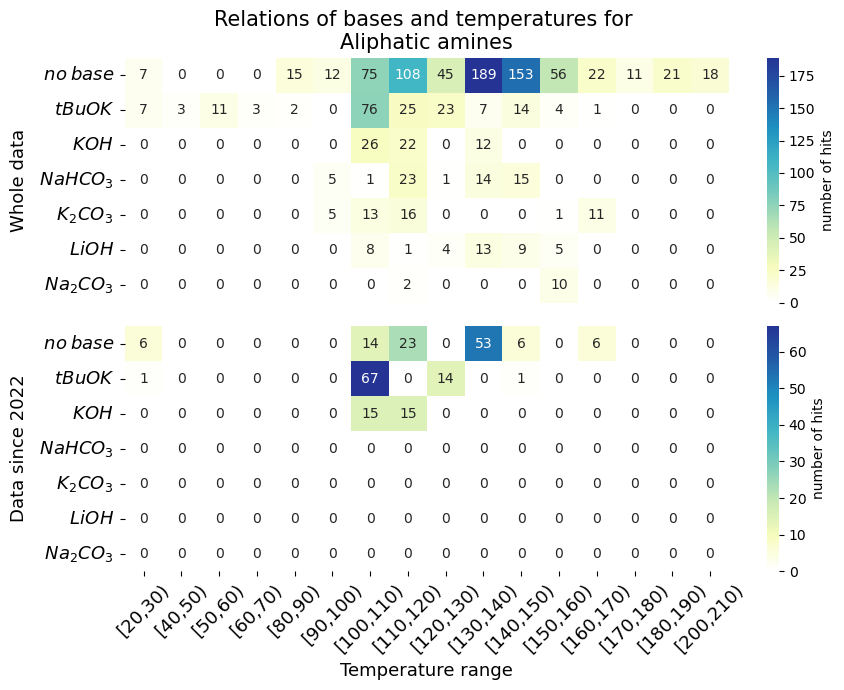

In [69]:
filter_val = 5
pf.plot_diff_graph(    
    df_substr_hb.loc[(df_substr_hb['success']) & (df_substr_hb['nucleophile']=='aliphatic')],  
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (9, 7),
    xlabel = 'Temperature range',
    title = 'Relations of bases and temperatures for \nAliphatic amines',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 5 times are neglected


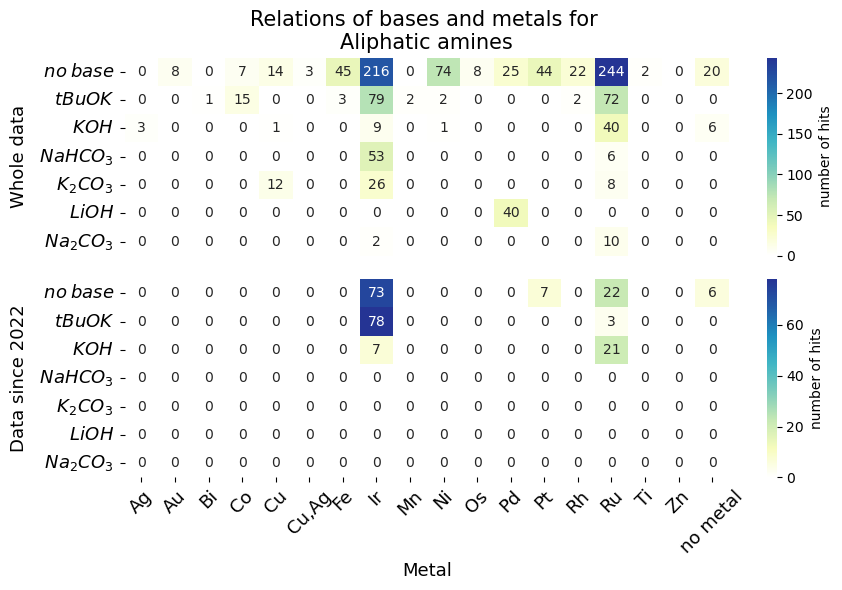

In [70]:
filter_val = 5
pf.plot_diff_graph(    
    df_substr_hb.loc[(df_substr_hb['success']) & (df_substr_hb['nucleophile']=='aliphatic')], 
    'base', 
    'metal',
    filter_val = filter_val,
    figsize = (9, 6),
    xlabel = 'Metal',
    title = 'Relations of bases and metals for \nAliphatic amines',
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


In [71]:
nucl_types = list(set(df_substr_hb['nucleophile'].to_list()))
nucl_types

['heteroaromatic', 'aliphatic', 'amide', 'aromatic']

In [72]:
for nucl_name in nucl_types:
    df = df_substr_hb[df_substr_hb['nucleophile'] == nucl_name]
    leaders = pf.get_cat_leaders(df)
    document = pf.create_document(leaders, title = f'Best catalyst for different {nucl_name + ' amines' if nucl_name != 'amide' else 'amides'}')
    document.save(os.path.join('doc_tables', f'best_cats_{nucl_name}.docx'))

### Whole substrate analysis 

Bases appeared less then 30 times were neglected


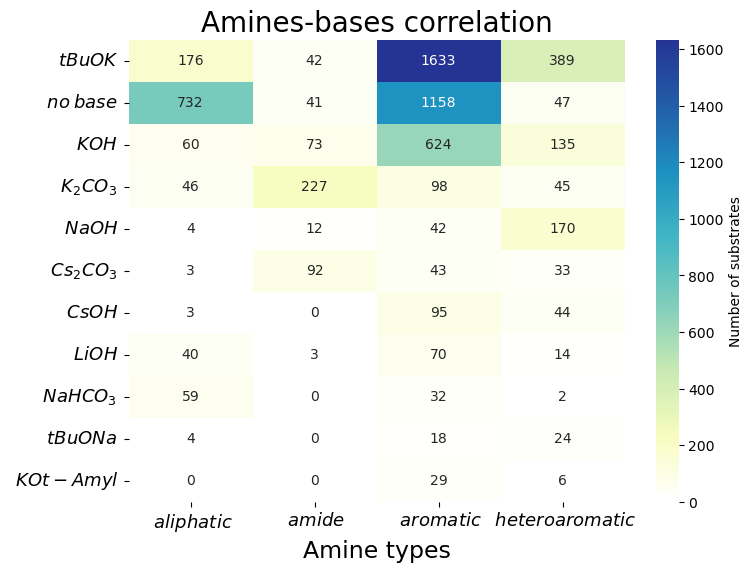

In [73]:
pf.d3_diagram(
    df_substr_hb[df_substr_hb['success']], 
    'base', 
    'nucleophile', 
    'Amines-bases correlation', 
    rotation_x_ticks='horizontal', 
    figsize=(8,6), 
    title_font=20,
    xlabel_font=17, 
    c_mp = 'Number of substrates', 
    filter_val =30,
    man_x_label=True, 
    x_label='Amine types' 
)
print('Bases appeared less then 30 times were neglected')

In [74]:
df_substr_hb['alc_type'].value_counts()

alc_type
ArCH2OH      5783
AlkCH2OH     1445
Alk2CHOH      435
AlkArCHOH     245
Ar2CHOH       172
Name: count, dtype: int64

Bases appeared less then 30 times were neglected


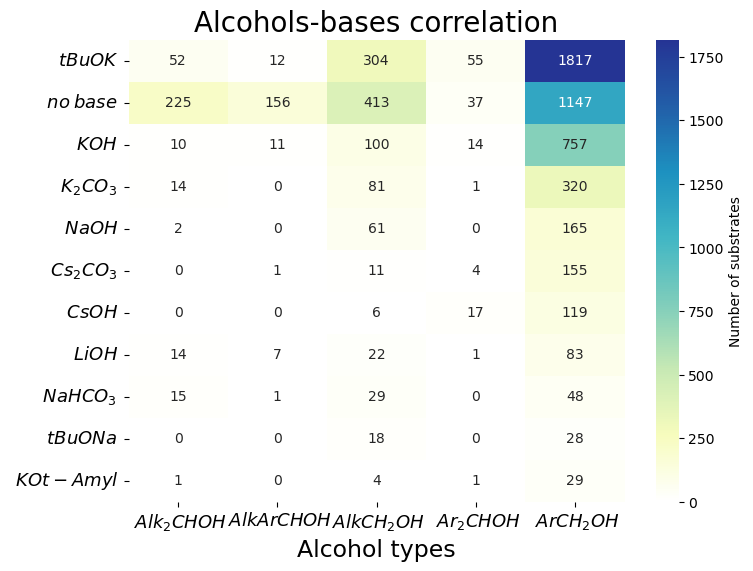

In [75]:
pf.d3_diagram(
    df_substr_hb[df_substr_hb['success']], 
    'base', 
    'alc_type', 
    'Alcohols-bases correlation', 
    rotation_x_ticks='horizontal', 
    figsize=(8,6), 
    title_font=20,
    xlabel_font=17, 
    c_mp = 'Number of substrates', 
    filter_val =30,
    man_x_label=True, 
    x_label='Alcohol types' 
)
print('Bases appeared less then 30 times were neglected')

# Amination of alcohols using nitro-group derivatives

In [8]:
#only BH reactions
nitro = ['ArNO2', 'AlkNO2', 'HetNO2']
df_substr_nitro = df_substr[df_substr['amine_type'].isin(nitro)]
df_substr_nitro.shape

(622, 24)

In [9]:
df_nitro.shape # optimization

(307, 21)

In [10]:
df_substr_nitro = df_substr_nitro[df_substr_nitro['atmosphere'] != 'H2'].copy()
df_nitro = df_nitro[df_nitro['atmosphere'] != 'H2'].copy()
#remove reductive atmosphere 

In [11]:
df_nitro['atmosphere'].value_counts()

atmosphere
N2         169
Ar         110
air         20
no data      6
inert        2
Name: count, dtype: int64

In [12]:
df_substr_nitro['atmosphere'].value_counts()

atmosphere
Ar         276
N2         154
no data     71
inert       54
air         45
air?        16
Name: count, dtype: int64

In [17]:
df_nitro['atm_type'] = df_nitro['atmosphere'].map({'N2': 'inert', 'Ar': 'inert', 'air': 'air', 'inert': 'inert'})

In [22]:
df_nitro['atm_type'].value_counts()

atm_type
inert    281
air       20
Name: count, dtype: int64

In [23]:
df_nitro[df_nitro['success']]['atm_type'].value_counts()

atm_type
inert    81
air       1
Name: count, dtype: int64

In [13]:
def get_activity(ton):
    if ton >=500:
        return 'active'
    elif ton>=100:
        return 'medium'
    else:
        return 'low'
cat_df = pd.concat([
    df_nitro[['doi', 'catalyst', 'metal', 'ligand','cat_load', 'yield', 'TON', 'base']],
    df_substr_nitro[['doi','catalyst', 'metal', 'ligand', 'metal_load', 'yield', 'TON', 'base']].rename(columns = {'metal_load': 'cat_load'})
])
cat_df.dropna(subset = 'TON', inplace = True)
cat_df.dropna(subset = 'metal', inplace = True)
cat_df = cat_df[cat_df['metal'].apply(lambda x: len(x.split(',')) == 1)].copy()
cat_df = cat_df[cat_df['cat_load'] > 0]
cat_df = cat_df[cat_df['TON'] > 5].copy()
cat_df = cat_df[cat_df['TON'] < 100000000000].copy()
cat_df.sort_values(by = 'TON', ascending = False, inplace = True)
cat_df.drop_duplicates(subset = ['catalyst', 'ligand', 'doi'], inplace = True)
cat_df.reset_index(drop = True, inplace = True)
cat_df['activity'] = cat_df['TON'].apply(get_activity)
print(f'We have {cat_df.shape[0]} different catalysts')

We have 125 different catalysts


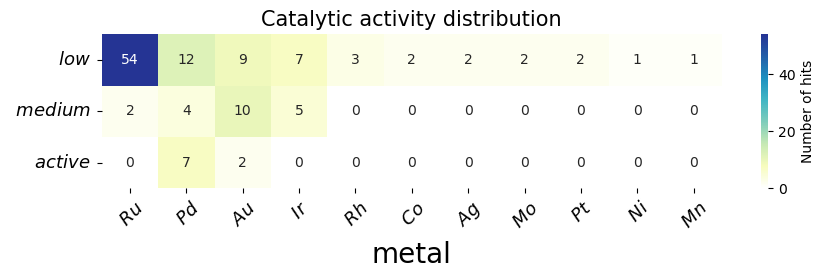

In [14]:
pf.d3_diagram(    
    cat_df, 
    'activity', 
    'metal',
    filter_val = 0,
    figsize = (10, 2),
    x_label = 'Metal',
    title = 'Catalytic activity distribution',
    title_font=15,
    sort_horizontal = True,
    rotation_x_ticks = 45
)


## Analysis of PhNO<sub>2</sub> + BnOH 

In [24]:
df_nitro['atm_type'] = df_nitro['atmosphere'].map({'N2': 'inert', 'Ar': 'inert', 'air': 'oxygen', 'no data': 'no_data', 'H2': 'H2', 'inert': 'inert' })

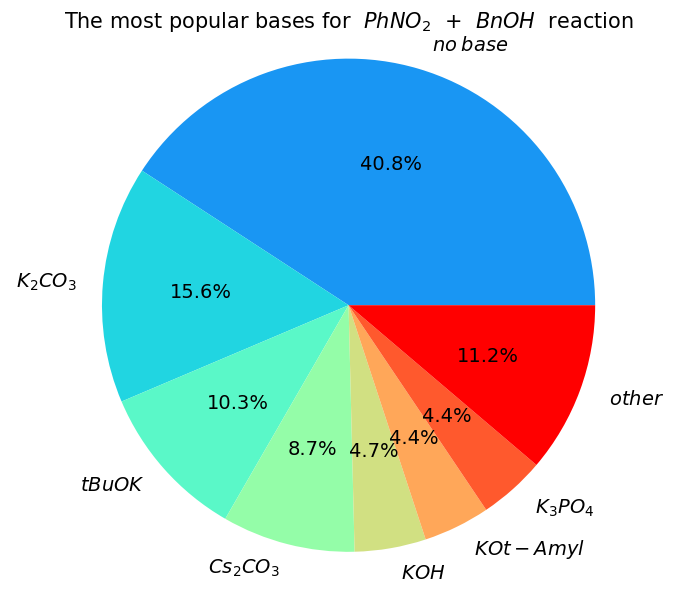

In [25]:
# bases 
limit_number = 7
base_pie = pf.get_parameter_pie_df(df_nitro, 'base', limit_number)[0]

fig1, ax1 = plt.subplots(figsize=(7, 7)) 
values = np.linspace(0.2, 1, limit_number+1)
colors = cm.rainbow(values)
ax1.pie(base_pie['count'], labels=[pf.to_chem(x) for x in base_pie.index], autopct='%1.1f%%', textprops={'fontsize': 14}, colors=colors)

ax1.axis('equal')
ax1.set_title(f'The most popular bases for {pf.to_chem('PhNO2')} + {pf.to_chem('BnOH')} reaction', fontsize = 15);

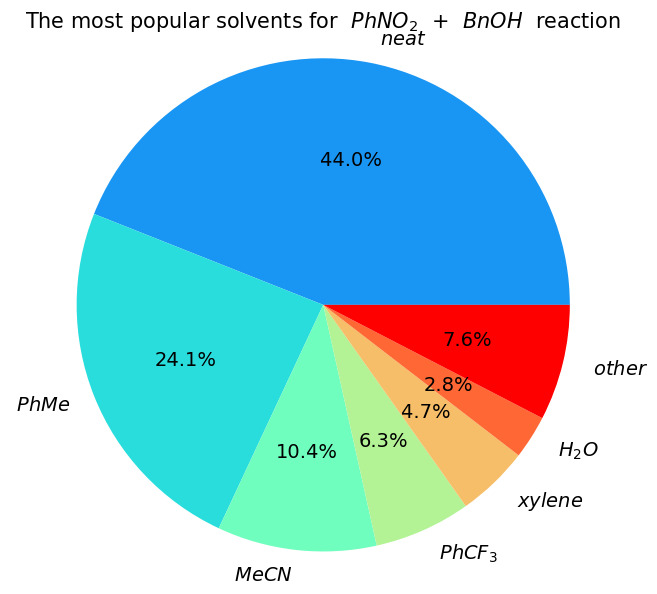

In [35]:
# bases 
limit_number = 6
base_pie = pf.get_parameter_pie_df(df_nitro, 'solvent', limit_number)[0]

fig1, ax1 = plt.subplots(figsize=(7, 7)) 
values = np.linspace(0.2, 1, limit_number+1)
colors = cm.rainbow(values)
ax1.pie(base_pie['count'], labels=[pf.to_chem(x) for x in base_pie.index], autopct='%1.1f%%', textprops={'fontsize': 14}, colors=colors)

ax1.axis('equal')
ax1.set_title(f'The most popular solvents for {pf.to_chem('PhNO2')} + {pf.to_chem('BnOH')} reaction', fontsize = 15);

In [26]:
df_nitro['success'] = df_nitro['yield']>65

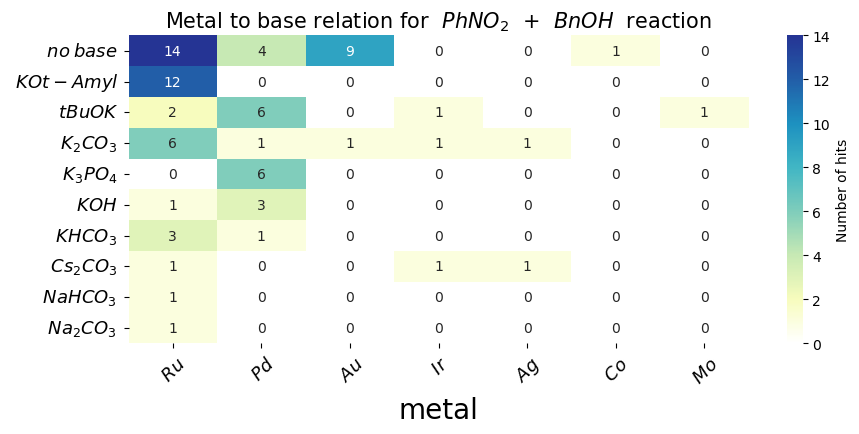

In [27]:
pf.d3_diagram(    
    df_nitro[df_nitro['success']], 
    'base', 
    'metal',
    filter_val = 0,
    figsize = (10, 4),
    x_label = 'Metal',
    title = f'Metal to base relation for {pf.to_chem('PhNO2')} + {pf.to_chem('BnOH')} reaction',
    title_font=15,
    sort_horizontal = True,
    rotation_x_ticks = 45
)

In [28]:
#add temp range
step = 10 #degrees centigrade
def get_temp_range(temp):
    num_range = int(temp/step)
    label = f'[{num_range*step},{(num_range+1)*step})'
    return num_range, label

df_nitro['num_temp_range'], df_nitro['label_temp_range'] = zip(*df_nitro['temp'].apply(get_temp_range))

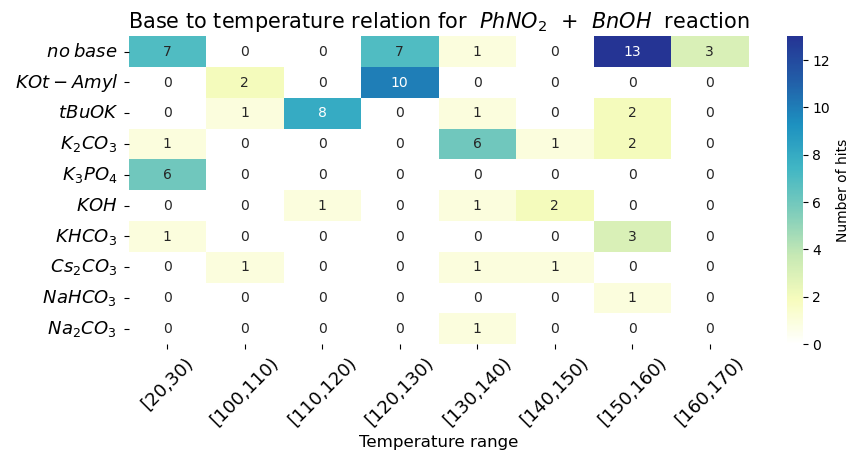

In [29]:
pf.d3_diagram(    
    df_nitro[df_nitro['success']], 
    'base', 
    'num_temp_range',
    filter_val = 0,
    figsize = (10, 4),
    man_x_label = True,
    x_label = 'Temperature range',
    title = f'Base to temperature relation for {pf.to_chem('PhNO2')} + {pf.to_chem('BnOH')} reaction',
    title_font=15,
    xlabel_font = 12,
    # sort_horizontal = True,
    rotation_x_ticks = 45,
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    tochem_x=False
)

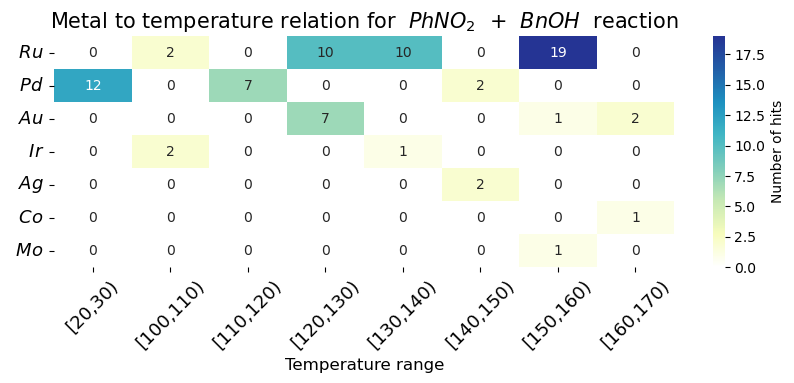

In [31]:
pf.d3_diagram(    
    df_nitro[df_nitro['success']], 
    'metal', 
    'num_temp_range',
    filter_val = 0,
    figsize = (10, 3),
    man_x_label = True,
    x_label = 'Temperature range',
    title = f'Metal to temperature relation for {pf.to_chem('PhNO2')} + {pf.to_chem('BnOH')} reaction',
    title_font=15,
    xlabel_font = 12,
    # sort_horizontal = True,
    rotation_x_ticks = 45,
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    tochem_x=False
)

In [32]:
mdf = df_nitro['metal'].value_counts().reset_index()
print('The most popular metals by the number of hits are')
mdf[mdf['count'] > 10]

The most popular metals by the number of hits are


,metal,count
0,Ru,129
1,Pd,54
2,Au,32
3,Ir,12


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


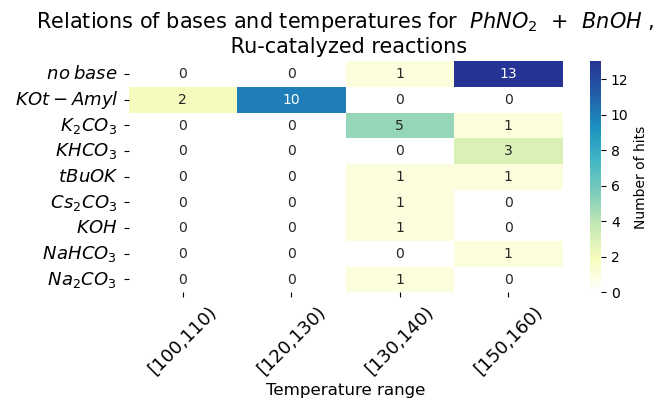

In [92]:
filter_val = 0
metal = 'Ru'
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')
pf.d3_diagram(    
    df_nitro[(df_nitro['success']) & (df_nitro['metal'] == metal)], 
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (7, 3),
    man_x_label = True,
    x_label = 'Temperature range',
    title = f'Relations of bases and temperatures for {pf.to_chem('PhNO2')} + {pf.to_chem('BnOH')},\n {metal}-catalyzed reactions',
    title_font=15,
    xlabel_font = 12,
    # sort_horizontal = True,
    rotation_x_ticks = 45,
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    tochem_x=False
)


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


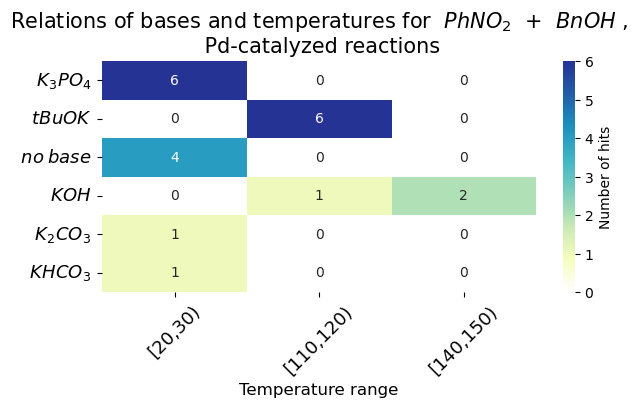

In [93]:
filter_val = 0
metal = 'Pd'
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')
pf.d3_diagram(    
    df_nitro[(df_nitro['success']) & (df_nitro['metal'] == metal)], 
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (7, 3),
    man_x_label = True,
    x_label = 'Temperature range',
    title = f'Relations of bases and temperatures for {pf.to_chem('PhNO2')} + {pf.to_chem('BnOH')},\n {metal}-catalyzed reactions',
    title_font=15,
    xlabel_font = 12,
    # sort_horizontal = True,
    rotation_x_ticks = 45,
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    tochem_x=False
)

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


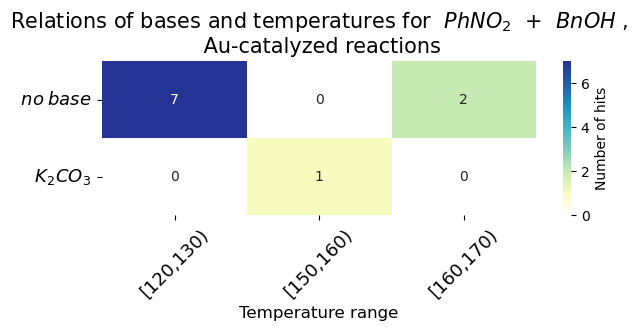

In [94]:
filter_val = 0
metal = 'Au'
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')
pf.d3_diagram(    
    df_nitro[(df_nitro['success']) & (df_nitro['metal'] == metal)], 
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (7, 2),
    man_x_label = True,
    x_label = 'Temperature range',
    title = f'Relations of bases and temperatures for {pf.to_chem('PhNO2')} + {pf.to_chem('BnOH')},\n {metal}-catalyzed reactions',
    title_font=15,
    xlabel_font = 12,
    # sort_horizontal = True,
    rotation_x_ticks = 45,
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    tochem_x=False
)

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


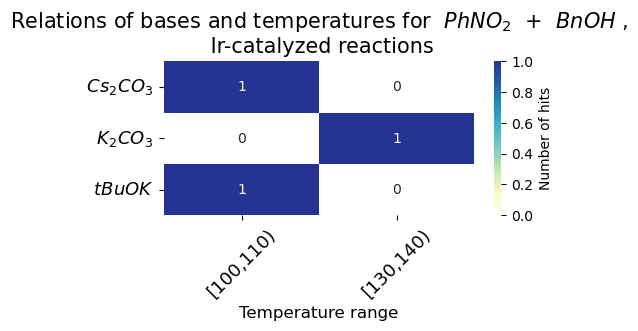

In [95]:
filter_val = 0
metal = 'Ir'
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')
pf.d3_diagram(    
    df_nitro[(df_nitro['success']) & (df_nitro['metal'] == metal)], 
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (5, 2),
    man_x_label = True,
    x_label = 'Temperature range',
    title = f'Relations of bases and temperatures for {pf.to_chem('PhNO2')} + {pf.to_chem('BnOH')},\n {metal}-catalyzed reactions',
    title_font=15,
    xlabel_font = 12,
    # sort_horizontal = True,
    rotation_x_ticks = 45,
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    tochem_x=False
)

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


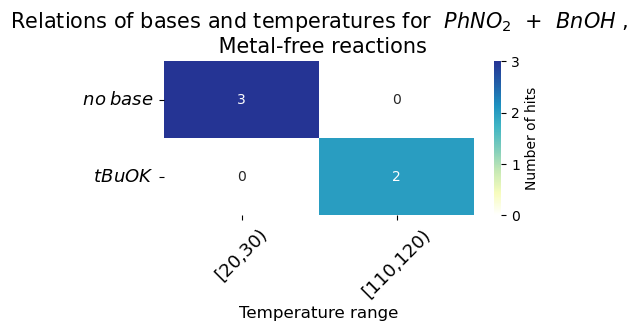

In [96]:
filter_val = 0
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')
pf.d3_diagram(    
    df_nitro[(df_nitro['success']) & (df_nitro['metal'].isna())], 
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (5, 2),
    man_x_label = True,
    x_label = 'Temperature range',
    title = f'Relations of bases and temperatures for {pf.to_chem('PhNO2')} + {pf.to_chem('BnOH')},\n Metal-free reactions',
    title_font=15,
    xlabel_font = 12,
    # sort_horizontal = True,
    rotation_x_ticks = 45,
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    tochem_x=False
)

## Metal leaders for PhNO<sub>2</sub> + BnOH reaction

In [97]:
metals = list(set(df_nitro['metal'].to_list()))
metals = [x for x in metals if (x != '0' and x is not None)]
metal_leaders = []
for metal in metals:
    metal_df = df_nitro[df_nitro['metal'] == metal]
    metal_df = metal_df.loc[(metal_df['TON'] < 100000) & (metal_df['TON']>5)]
    record = {'metal': metal}
    record['num_papers'] =  len(set(metal_df['doi'].to_list()))
    # max ton maximal TON among all (TONmax(1)/T,°C/base/catalyst typea/atmosphere)
    best = metal_df.sort_values(by = 'TON', ascending = False).to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['max_ton'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['comment']})'
    else:
        record['max_ton'] = 'no data'
    # maximal TON among the processes with preparative yields (TONmax(2)/T,°C/base/catalyst typea/atmosphere)
    best = metal_df[metal_df['yield']>65].sort_values(by = 'TON', ascending = False).to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['max_ton_prep'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['comment']})'
    else:
        record['max_ton_prep'] = 'no data'
    #the lowest temperature in the presence of base (TON/Tmin(1),°C/base/catalyst typea/atmosphere)
    best = metal_df[metal_df['yield']>65].sort_values(by = 'temp').to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['min_temp'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['comment']})'
    else:
        record['min_temp'] = 'no data'
    #the highest TON in the absence of base (TONmax(3)/T,°C/base/catalyst typea/atmosphere)
    best = metal_df[metal_df['base']=='no base'].sort_values(by = 'TON', ascending = False).to_dict('records')
    if len(best):
        best = best[0]  
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['max_ton_no_base'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['comment']})'
    else:
        record['max_ton_no_base'] = 'no data'
        
    #The lowest temperature in the absence of base (TON/Tmin(2),°C/base/catalyst typea/atmosphere)
    best = metal_df.loc[metal_df['base']=='no base'].loc[metal_df['yield']>65].sort_values(by = 'temp').to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['min_temp_no_base'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['comment']})'
    else:
        record['min_temp_no_base'] = 'no data'
    bases = metal_df[metal_df['yield']>65]['base'].value_counts().index.to_list()
    if len(bases) > 1:
        record['most_popular_working_bases']= bases[0:3]
    else:
        record['most_popular_working_bases']= bases
    metal_leaders.append(record)
metal_leaders = sorted(metal_leaders, key = lambda x: x['num_papers'], reverse = True)
metal_leaders = [x for x in metal_leaders if x['num_papers'] > 0]

In [98]:
pd.DataFrame(metal_leaders)

,metal,num_papers,max_ton,max_ton_prep,min_temp,max_ton_no_base,min_temp_no_base,most_popular_working_bases
0,Ru,9,(97/150.0°C/tBuOK/Ru(II)L1Cl(CO)2 (4)/inert/10.1002/ejic.201100647/L=C6H4(o-PPh2)(o-N=CH)C6H4(O)),(97/150.0°C/tBuOK/Ru(II)L1Cl(CO)2 (4)/inert/10.1002/ejic.201100647/L=C6H4(o-PPh2)(o-N=CH)C6H4(O)),(26/100.0°C/KOt-Amyl/(p-cymene)Ru(NHC1^NHC1)ClPF6/inert/10.1002/chem.201603901/0),(84/150.0°C/no base/Ru(CO)H2(PPh3)3/inert/10.1002/asia.201000945/0),(27/130.0°C/no base/Ru(CO)H2(PPh3)3/inert/10.1021/ol1020527/0),"[no base, KOt-Amyl, K2CO3]"
1,Pd,4,"(960/25.0°C/K3PO4/Pd/NH2-MIL-101(Fe)-2MI(300)/inert/10.1016/j.jcat.2020.05.033/blue LED (0,75W cm-2))","(960/25.0°C/K3PO4/Pd/NH2-MIL-101(Fe)-2MI(300)/inert/10.1016/j.jcat.2020.05.033/blue LED (0,75W cm-2))",(227/25.0°C/no base/Pd-Ti-NS/inert/10.1016/j.jcat.2018.02.005/<700nm),(227/25.0°C/no base/Pd-Ti-NS/inert/10.1016/j.jcat.2018.02.005/<700nm),(227/25.0°C/no base/Pd-Ti-NS/inert/10.1016/j.jcat.2018.02.005/<700nm),"[K3PO4, tBuOK, KOH]"
2,Au,4,(1517/150.0°C/K2CO3/Au/Ag-Mo-NR/inert/10.1039/c2cc34178f/0),(1517/150.0°C/K2CO3/Au/Ag-Mo-NR/inert/10.1039/c2cc34178f/0),(144/120.0°C/no base/Au/TiO2-VS/inert/10.1002/chem.201100393/0),(228/160.0°C/no base/2.5 wt% Au/NiO/inert/10.1039/c1cc11057h/0),(144/120.0°C/no base/Au/TiO2-VS/inert/10.1002/chem.201100393/0),"[no base, K2CO3]"
3,Ir,4,(430/100.0°C/Cs2CO3/Cp*Ir(C^NHC2)I/oxygen/10.1021/acs.organomet.8b00642/0),(164/100.0°C/Cs2CO3/Cp*Ir(C^NHC2)I/oxygen/10.1021/acs.organomet.8b00642/0),(81/100.0°C/tBuOK/Cp*IrCl(N^O)1/inert/10.1021/acs.inorgchem.2c00703/0),no data,no data,"[tBuOK, Cs2CO3, K2CO3]"
4,Ni,1,(19/20.0°C/no base/Ni/CdS/inert/10.1016/j.jcat.2018.12.011/>420 nm),no data,no data,(19/20.0°C/no base/Ni/CdS/inert/10.1016/j.jcat.2018.12.011/>420 nm),no data,[]
5,Co,1,(6/160.0°C/no base/Co-N-C/CNT@AC/inert/10.1039/C8GC03818J/>420 nm),(6/160.0°C/no base/Co-N-C/CNT@AC/inert/10.1039/C8GC03818J/>420 nm),(6/160.0°C/no base/Co-N-C/CNT@AC/inert/10.1039/C8GC03818J/>420 nm),(6/160.0°C/no base/Co-N-C/CNT@AC/inert/10.1039/C8GC03818J/>420 nm),(6/160.0°C/no base/Co-N-C/CNT@AC/inert/10.1039/C8GC03818J/>420 nm),[no base]
6,Rh,1,(96/100.0°C/Cs2CO3/Cp*Rh(C^NHC2)I/oxygen/10.1021/acs.organomet.8b00642/0),no data,no data,no data,no data,[]
7,Ag,1,(45/140.0°C/Cs2CO3/Ag/Al2O3/inert/10.1039/C5CP00330J/0),(45/140.0°C/Cs2CO3/Ag/Al2O3/inert/10.1039/C5CP00330J/0),(41/140.0°C/K2CO3/Ag/Al2O3/inert/10.1039/C5CP00330J/0),(7/140.0°C/no base/Ag/Al2O3/inert/10.1039/C5CP00330J/0),no data,"[K2CO3, Cs2CO3]"
8,Mo,1,(16/150.0°C/tBuOK/Mo(NHC3)2(CO)4/inert/10.1021/acscatal.1c02956/0),(16/150.0°C/tBuOK/Mo(NHC3)2(CO)4/inert/10.1021/acscatal.1c02956/0),(16/150.0°C/tBuOK/Mo(NHC3)2(CO)4/inert/10.1021/acscatal.1c02956/0),no data,no data,[tBuOK]


In [99]:
document = Document()
data = metal_leaders
        
sections = document.sections
for section in sections:
    section.orientation = WD_ORIENT.LANDSCAPE

p = document.add_paragraph() 
run = p.add_run('Best catalysts by metals for PhNO2 + BnOH process')
run.font.size = Pt(14)
paragraph_format = p.paragraph_format
paragraph_format.alignment = WD_ALIGN_PARAGRAPH.CENTER
p = document.add_paragraph('Data stracture in all cells: (TONmax/T,°C/base/catalyst/atmosphere/doi/comment)') 

col_names = ['Metal', 'Number of papers', 
            'Maximal TON among all ', 
             'Maximal TON among the processes with preparative yields >65%',
                'The lowest temperature among all with preparative yields >65%',
             'The highest TON in the absence of base',
             'The lowest temperature in the absence of base with preparative yields >65%', 
            'most popular working bases']
table = document.add_table(rows= len(data) +1 , cols=len(col_names))
row = table.rows[0]
for idx, col_name in enumerate(col_names):
    
    for p in row.cells[idx].iter_inner_content():
        break
    run = p.add_run(col_name)
    run.bold = True
    
for row_idx, item in enumerate(data):
    row = table.rows[row_idx+1] #так как нулевой ряд - заголовок
    row.cells[0].text = item['metal']
    row.cells[1].text = str(item['num_papers'])
    row.cells[2].text = str(item['max_ton'])
    row.cells[3].text = str(item['max_ton_prep'])
    row.cells[4].text = str(item['min_temp'])
    row.cells[5].text = str(item['max_ton_no_base'])
    row.cells[6].text = str(item['min_temp_no_base'])
    row.cells[7].text = str(item['most_popular_working_bases'])
    

document.save(r'doc_tables\best_cats_PhNO2_BnOH.docx')

## Substrates

In [100]:
df_substr_nitro['amine_type'].value_counts()

amine_type
ArNO2     601
AlkNO2     11
HetNO2      4
Name: count, dtype: int64

In [101]:
# Nitro source is ArNO2 in most cases. Analyzing alcohols.

In [102]:
df_substr_nitro = df_substr_nitro[df_substr_nitro['alcohol_type'] != 'MeOH'] 

In [103]:
df_substr_nitro['alcohol_type'].value_counts()

alcohol_type
BnOH         237
AlkCH2OH      86
ArCH2OH       70
Alk2CHOH      32
AlkArCHOH     15
HetBnOH        7
Bn2OH          5
Name: count, dtype: int64

In [104]:
df_substr_nitro['success'] = df_substr_nitro['yield'] > 65

Bases appeared less then 30 times were neglected


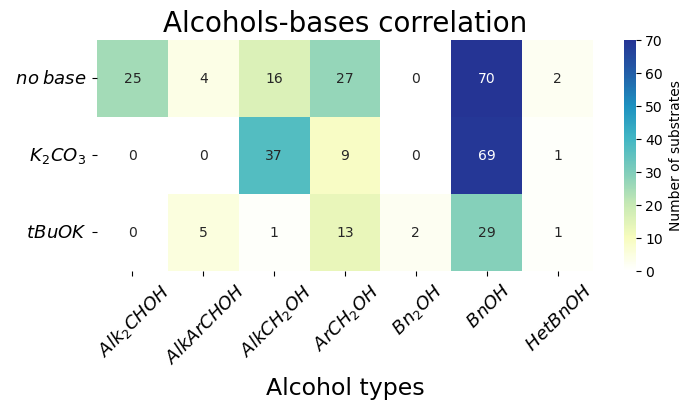

In [105]:
pf.d3_diagram(
    df_substr_nitro[df_substr_nitro['success'] ], 
    'base', 
    'alcohol_type', 
    'Alcohols-bases correlation', 
    rotation_x_ticks=45, 
    figsize=(8,3), 
    title_font=20,
    xlabel_font=17, 
    c_mp = 'Number of substrates', 
    filter_val =30,
    man_x_label=True, 
    x_label='Alcohol types' 
)
print('Bases appeared less then 30 times were neglected')

In [106]:
df_substr_nitro['num_temp_range'], df_substr_nitro['label_temp_range'] = zip(*df_substr_nitro['temp'].apply(get_temp_range))

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


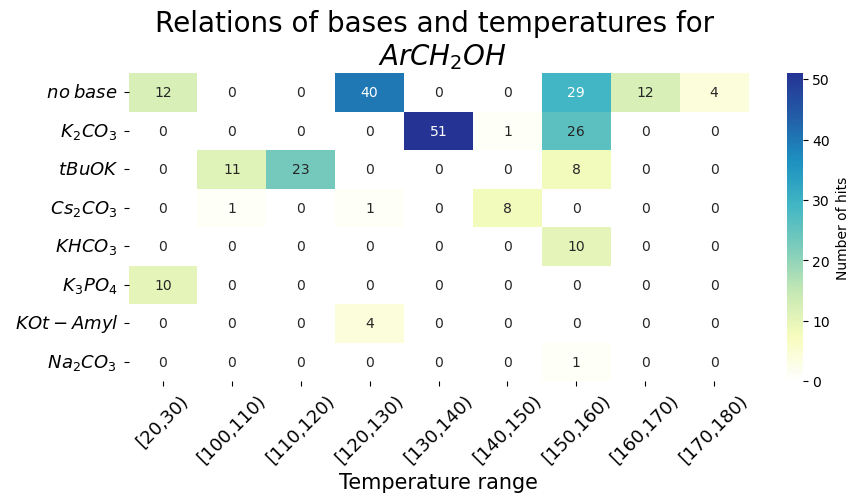

In [107]:
filter_val = 0
pf.d3_diagram(    
    df_substr_nitro.loc[(df_substr_nitro['success']) & (df_substr_nitro['alcohol_type'].isin(['BnOH', 'ArCH2OH']))],  
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (10, 4),
        man_x_label=True,
    x_label = 'Temperature range',
    xlabel_font = 15,
    rotation_x_ticks=45, 
    title_font=20,
    tochem_x = False,
    title = f'Relations of bases and temperatures for \n{pf.to_chem('ArCH2OH')}',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


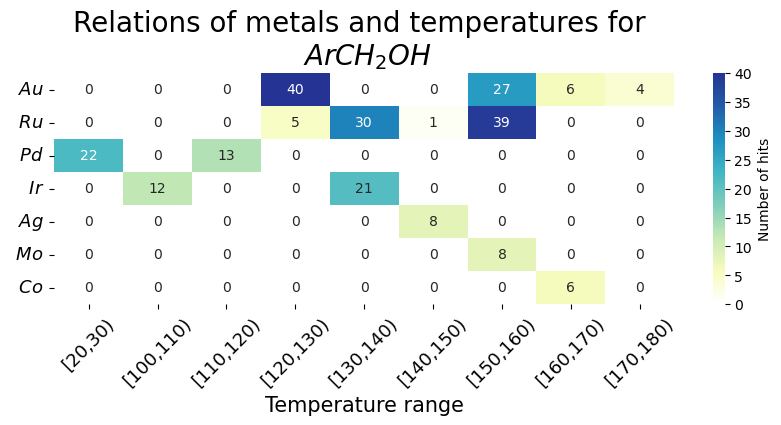

In [108]:
filter_val = 0
pf.d3_diagram(    
    df_substr_nitro.loc[(df_substr_nitro['success']) & (df_substr_nitro['alcohol_type'].isin(['BnOH', 'ArCH2OH']))],  
    'metal', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (10, 3),
    man_x_label=True,
    x_label = 'Temperature range',
    xlabel_font = 15,
    rotation_x_ticks=45, 
    title_font=20,
    tochem_x = False,
    title = f'Relations of metals and temperatures for \n{pf.to_chem('ArCH2OH')}',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


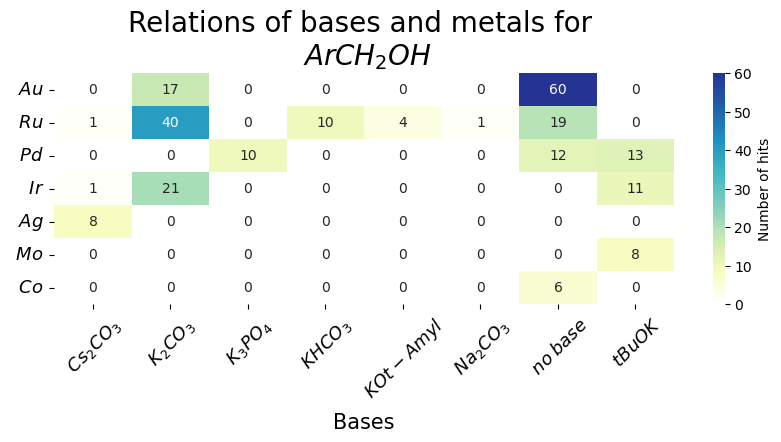

In [109]:
filter_val = 0
pf.d3_diagram(    
    df_substr_nitro.loc[(df_substr_nitro['success']) & (df_substr_nitro['alcohol_type'].isin(['BnOH', 'ArCH2OH']))],  
    'metal', 
    'base',
    filter_val = filter_val,
    figsize = (10, 3),
    man_x_label=True,
    x_label = 'Bases',
    xlabel_font = 15,
    rotation_x_ticks=45, 
    title_font=20,
    title = f'Relations of bases and metals for \n{pf.to_chem('ArCH2OH')}',
    # rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val} times are neglected')


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


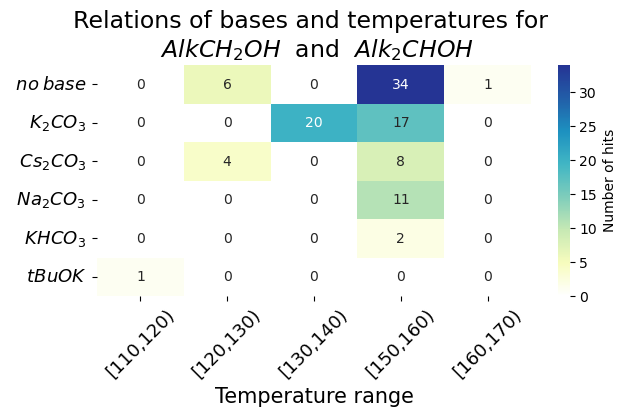

In [110]:
filter_val = 0
pf.d3_diagram(    
    df_substr_nitro.loc[(df_substr_nitro['success']) & (df_substr_nitro['alcohol_type'].isin(['AlkCH2OH', 'Alk2CHOH']))],  
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (7, 3),
        man_x_label=True,
    x_label = 'Temperature range',
    xlabel_font = 15,
    rotation_x_ticks=45, 
    title_font=17,
    tochem_x = False,
    title = f'Relations of bases and temperatures for \n{pf.to_chem('AlkCH2OH')} and {pf.to_chem('Alk2CHOH')}',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


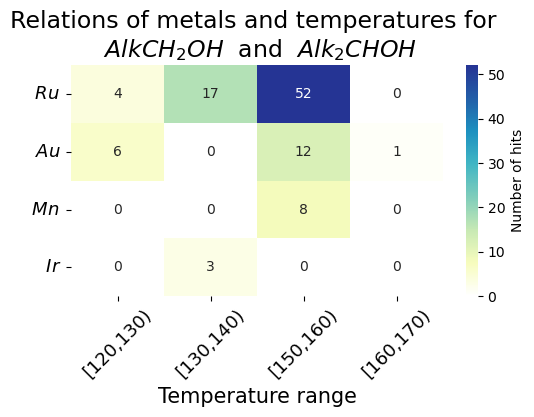

In [111]:
filter_val = 0
pf.d3_diagram(    
    df_substr_nitro.loc[(df_substr_nitro['success']) & (df_substr_nitro['alcohol_type'].isin(['AlkCH2OH', 'Alk2CHOH']))],  
    'metal', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (6, 3),
    man_x_label=True,
    x_label = 'Temperature range',
    xlabel_font = 15,
    rotation_x_ticks=45, 
    title_font=17,
    tochem_x = False,
    title = f'Relations of metals and temperatures for \n{pf.to_chem('AlkCH2OH')} and {pf.to_chem('Alk2CHOH')}',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


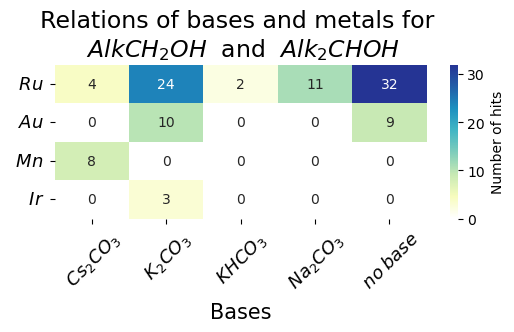

In [112]:
filter_val = 0
pf.d3_diagram(    
    df_substr_nitro.loc[(df_substr_nitro['success']) & (df_substr_nitro['alcohol_type'].isin(['AlkCH2OH', 'Alk2CHOH']))],  
    'metal', 
    'base',
    filter_val = filter_val,
    figsize = (6, 2),
    man_x_label=True,
    x_label = 'Bases',
    xlabel_font = 15,
    rotation_x_ticks=45, 
    title_font=17,
    title = f'Relations of bases and metals for \n{pf.to_chem('AlkCH2OH')} and {pf.to_chem('Alk2CHOH')}',
    # rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val} times are neglected')


In [113]:
bnoh_leaders = pf.get_cat_leaders(df_substr_nitro[df_substr_nitro['alcohol_type'].isin(['BnOH', 'ArCH2OH'])])
document = pf.create_document(bnoh_leaders, title = 'Best catalyst for different ArCH2OH')
document.save(r'doc_tables/best_cats_NO2_bnoh.docx')

In [114]:
alkoh_leaders = pf.get_cat_leaders(df_substr_nitro[df_substr_nitro['alcohol_type'].isin(['AlkCH2OH', 'Alk2CHOH'])])
document = pf.create_document(alkoh_leaders, title = 'Best catalyst for different AlkCH2OH and Alk2CHOH')
document.save(r'doc_tables/best_cats_NO2_alkoh.docx')

# MeOH 

In [115]:
df_meoh['N_source'].value_counts()

N_source
aniline                 199
nitroarene              176
 benzenesulfonamide      13
Name: count, dtype: int64

In [118]:
meoh_substr = df_substr[df_substr['alcohol_type'] == 'MeOH']

In [119]:
meoh_substr.columns

Index(['doi', 'solvent', 'amine_type', 'pKa_amine', 'n_amine', 'alcohol_type',
       'pKa_alcohol', 'n_alcohol', 'base', 'base_amount', 'catalyst', 'metal',
       'ligand', 'atmosphere', 'metal_load', 'temp', 'time', 'yield', 'TON',
       'atm_type', 'year', 'base_amine_ratio', 'base_alcohol_ratio',
       'reag_ratio'],
      dtype='str')

In [120]:
df_meoh['base'].value_counts()

base
tBuOK       82
Cs2CO3      73
MeONa       53
no base     52
KOH         28
K2CO3       27
MeOK        22
NaOH        16
Na2CO3       8
Et3N         5
tBuONa       4
K3PO4        4
tBuOLi       2
KHMDS        2
MeOLi        2
iPrONa       1
CsOH         1
TMEDA        1
LiOH         1
NaH          1
CsOH*H2O     1
NaOAc        1
KHCO3        1
Name: count, dtype: int64

In [121]:
df_meoh['metal'].value_counts()

metal
Ru    206
Pd     43
Ir     41
Mn     40
Ni     27
Re     16
Cu      4
Pt      1
Zn      1
Name: count, dtype: int64

In [122]:
cat_df = pd.concat([
    df_meoh[[ 'doi', 'catalyst', 'metal', 'ligand', 'TON', 'base', 'N_source', 'cat_load']].rename(columns = {'N_source': 'amine_type'}),
    meoh_substr[[ 'doi', 'catalyst', 'metal', 'ligand',  'TON', 'base', 'amine_type', 'metal_load']].rename(columns = {'metal_load': 'cat_load'})
])
substr_map = {}
for x in list(set(cat_df['amine_type'].to_list())):
    if 'NO2' in x or 'nitro' in x:
        substr_map[x] = 'nitro'
    else:
        substr_map[x] = 'amine'
cat_df['amine_type'] = cat_df['amine_type'].map(substr_map)
cat_df.dropna(subset = 'TON', inplace = True)
cat_df.dropna(subset = 'metal', inplace = True)
cat_df = cat_df[cat_df['metal'].apply(lambda x: len(x.split(',')) == 1)].copy()
cat_df = cat_df[cat_df['cat_load'] > 0]
cat_df = cat_df[cat_df['TON'] > 5].copy()
cat_df = cat_df[cat_df['TON'] < 100000000000].copy()
cat_df.sort_values(by = 'TON', ascending = False, inplace = True)
cat_df.drop_duplicates(subset = ['catalyst', 'ligand', 'doi'], inplace = True)
cat_df.reset_index(drop = True, inplace = True)
cat_df['activity'] = cat_df['TON'].apply(get_activity)
print(f'We have {cat_df.shape[0]} different catalysts')

We have 118 different catalysts


In [123]:
cat_df['activity'].value_counts()

activity
low       94
medium    21
active     3
Name: count, dtype: int64

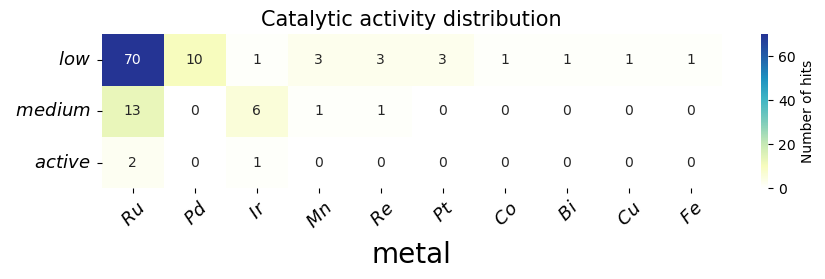

In [124]:
pf.d3_diagram(    
    cat_df, 
    'activity', 
    'metal',
    filter_val = 0,
    figsize = (10, 2),
    x_label = 'Metal',
    title = 'Catalytic activity distribution',
    title_font=15,
    sort_horizontal = True,
    rotation_x_ticks = 45
)


In [125]:
cat_df['amine_type'].value_counts()

amine_type
amine    71
nitro    47
Name: count, dtype: int64

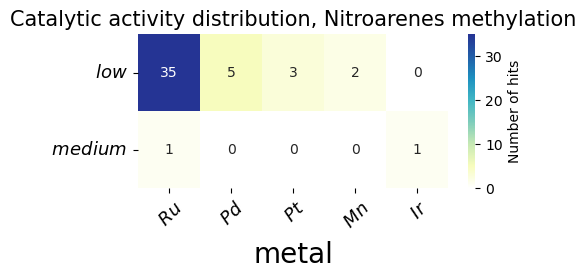

In [126]:
pf.d3_diagram(    
    cat_df[cat_df['amine_type'] == 'nitro'] , 
    'activity', 
    'metal',
    filter_val = 0,
    figsize = (5, 2),
    x_label = 'Metal',
    title = 'Catalytic activity distribution, Nitroarenes methylation',
    title_font=15,
    sort_horizontal = True,
    rotation_x_ticks = 45
)

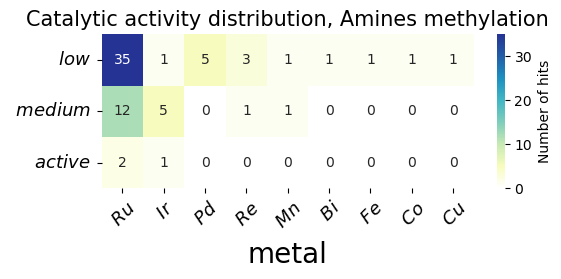

In [127]:
pf.d3_diagram(    
    cat_df[cat_df['amine_type'] == 'amine'] , 
    'activity', 
    'metal',
    filter_val = 0,
    figsize = (6, 2),
    x_label = 'Metal',
    title = 'Catalytic activity distribution, Amines methylation',
    title_font=15,
    sort_horizontal = True,
    rotation_x_ticks = 45
)

In [128]:
df_meoh['success'] = df_meoh.apply(lambda x: x['yield_PhNHMe'] + x['yield_PhN(Me)2'] > 65, axis = 1)

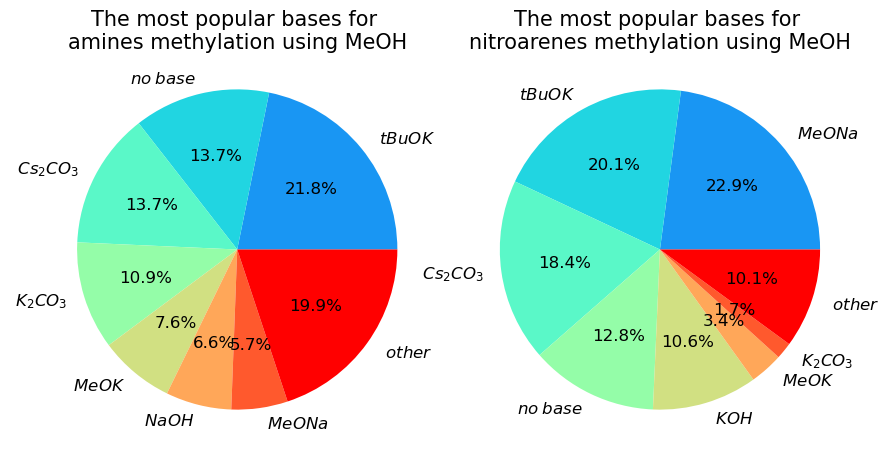

In [129]:
# bases 
limit_number = 7
plt.figure(figsize=(10,5))
ax1 = plt.subplot(1, 2, 1) 
base_pie = pf.get_parameter_pie_df(df_meoh[df_meoh['N_source'] == 'aniline'], 'base', limit_number)[0]
values = np.linspace(0.2, 1, limit_number+1)
colors = cm.rainbow(values)
ax1.pie(base_pie['count'], labels=[pf.to_chem(x) for x in base_pie.index], autopct='%1.1f%%', textprops={'fontsize': 12}, colors=colors)

ax1.axis('equal')
ax1.set_title(f'The most popular bases for \namines methylation using MeOH', fontsize = 15);

ax1 = plt.subplot(1, 2, 2) 
base_pie = pf.get_parameter_pie_df(df_meoh[df_meoh['N_source'] == 'nitroarene'], 'base', limit_number)[0]
values = np.linspace(0.2, 1, limit_number+1)
colors = cm.rainbow(values)
ax1.pie(base_pie['count'], labels=[pf.to_chem(x) for x in base_pie.index], autopct='%1.1f%%', textprops={'fontsize': 12}, colors=colors)

ax1.axis('equal')
ax1.set_title(f'The most popular bases for \nnitroarenes methylation using MeOH', fontsize = 15);

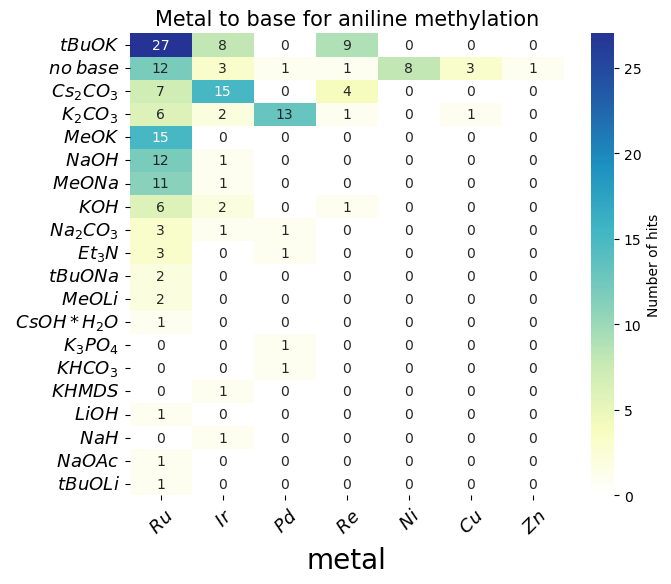

In [130]:
pf.d3_diagram(    
    df_meoh[df_meoh['N_source'] == 'aniline'] , 
    'base', 
    'metal',
    filter_val = 0,
    figsize = (7, 6),
    x_label = 'Metal',
    title = 'Metal to base for aniline methylation',
    title_font=15,
    sort_horizontal = True,
    rotation_x_ticks = 45
)

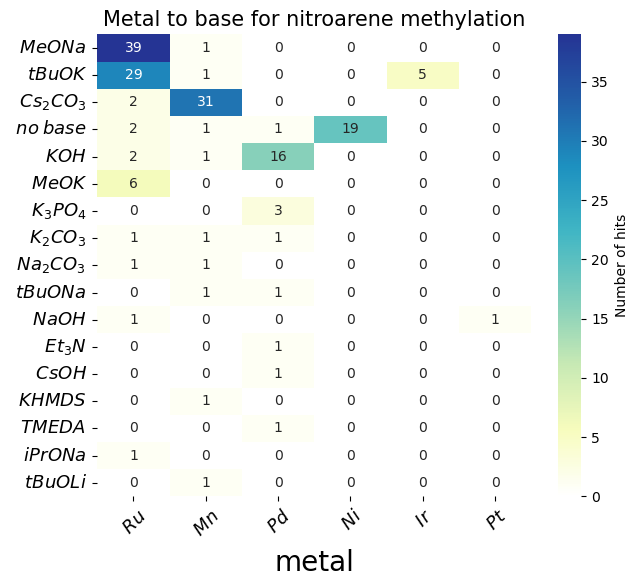

In [131]:
pf.d3_diagram(    
    df_meoh[df_meoh['N_source'] == 'nitroarene'] , 
    'base', 
    'metal',
    filter_val = 0,
    figsize = (7, 6),
    x_label = 'Metal',
    title = 'Metal to base for nitroarene methylation',
    title_font=15,
    sort_horizontal = True,
    rotation_x_ticks = 45
)

In [132]:
df_meoh['num_temp_range'], df_meoh['label_temp_range'] = zip(*df_meoh['temp'].apply(get_temp_range))

Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


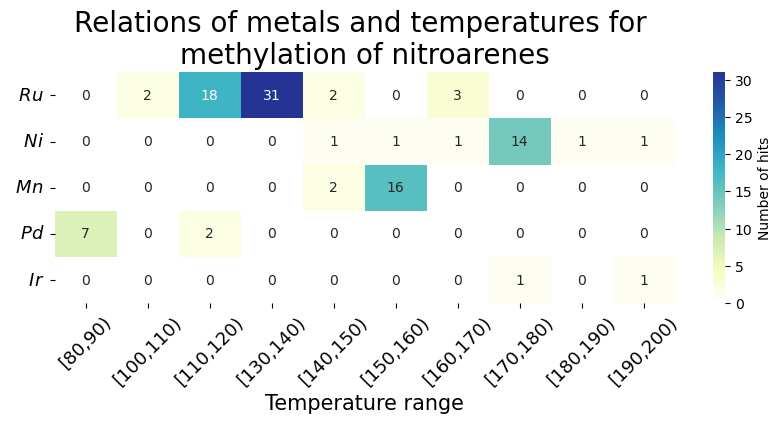

In [133]:
filter_val = 0
pf.d3_diagram(    
    df_meoh.loc[(df_meoh['success']) & (df_meoh['N_source'] == 'nitroarene')],  
    'metal', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (10, 3),
    man_x_label=True,
    x_label = 'Temperature range',
    xlabel_font = 15,
    rotation_x_ticks=45, 
    title_font=20,
    tochem_x = False,
    title = f'Relations of metals and temperatures for \nmethylation of nitroarenes',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


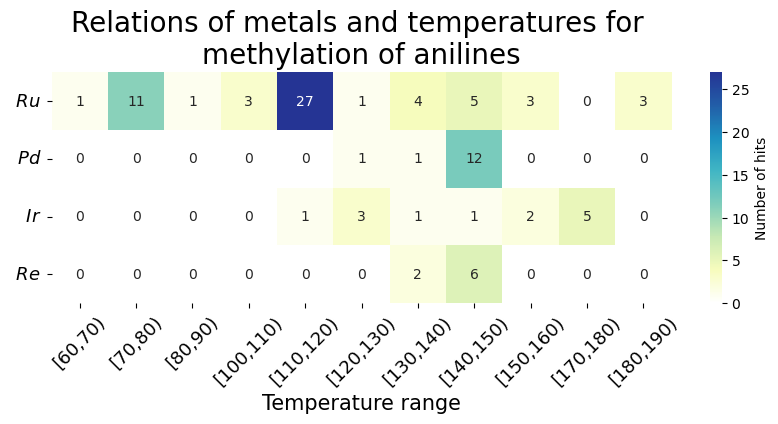

In [134]:
filter_val = 0
pf.d3_diagram(    
    df_meoh.loc[(df_meoh['success']) & (df_meoh['N_source'] == 'aniline')],  
    'metal', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (10, 3),
    man_x_label=True,
    x_label = 'Temperature range',
    xlabel_font = 15,
    rotation_x_ticks=45, 
    title_font=20,
    tochem_x = False,
    title = f'Relations of metals and temperatures for \nmethylation of anilines',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


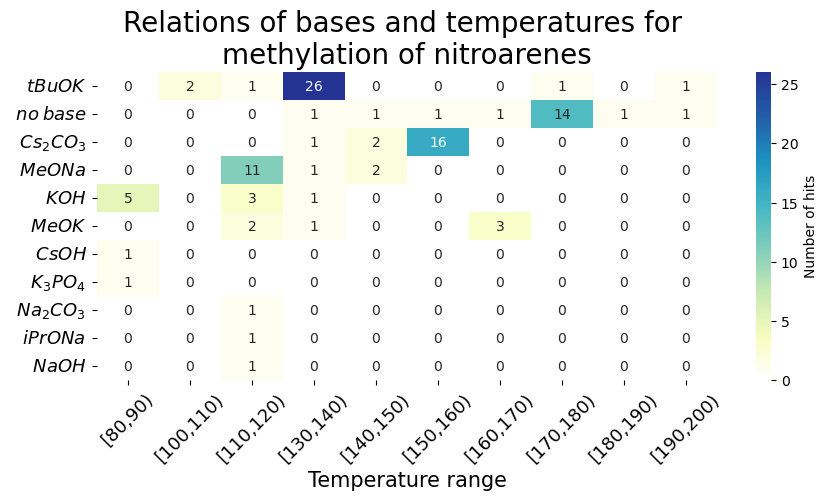

In [135]:
filter_val = 0
pf.d3_diagram(    
    df_meoh.loc[(df_meoh['success']) & (df_meoh['N_source'] == 'nitroarene')],  
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (10, 4),
    man_x_label=True,
    x_label = 'Temperature range',
    xlabel_font = 15,
    rotation_x_ticks=45, 
    title_font=20,
    tochem_x = False,
    title = f'Relations of bases and temperatures for \nmethylation of nitroarenes',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


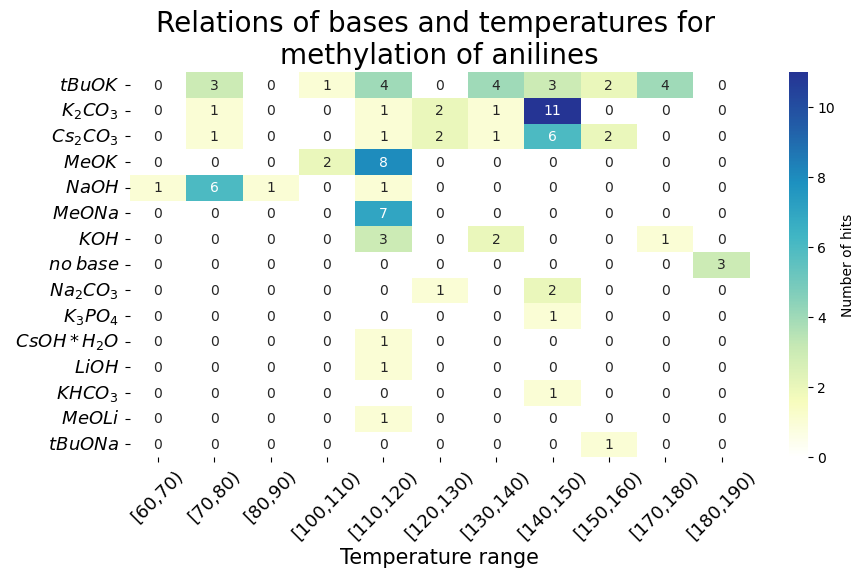

In [136]:
filter_val = 0
pf.d3_diagram(    
    df_meoh.loc[(df_meoh['success']) & (df_meoh['N_source'] == 'aniline')],  
    'base', 
    'num_temp_range',
    filter_val = filter_val,
    figsize = (10, 5),
    man_x_label=True,
    x_label = 'Temperature range',
    xlabel_font = 15,
    rotation_x_ticks=45, 
    title_font=20,
    tochem_x = False,
    title = f'Relations of bases and temperatures for \nmethylation of anilines',
    rename_x_ticks_dict = {idx: f'[{idx*10},{(idx+1)*10})' for idx in range(25)},
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


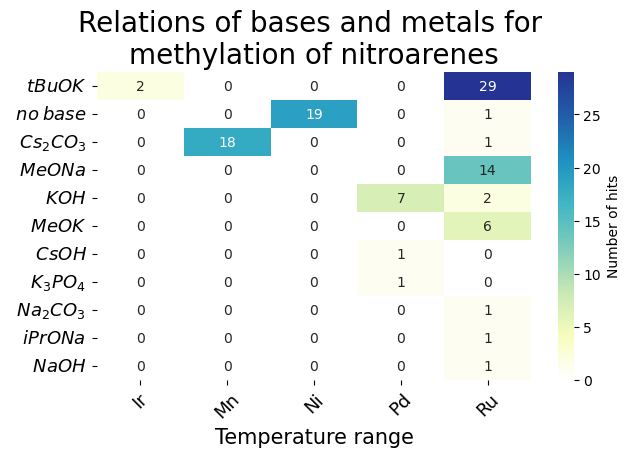

In [137]:
filter_val = 0
pf.d3_diagram(    
    df_meoh.loc[(df_meoh['success']) & (df_meoh['N_source'] == 'nitroarene')],  
    'base', 
    'metal',
    filter_val = filter_val,
    figsize = (7, 4),
    man_x_label=True,
    x_label = 'Temperature range',
    xlabel_font = 15,
    rotation_x_ticks=45, 
    title_font=20,
    tochem_x = False,
    title = f'Relations of bases and metals for \nmethylation of nitroarenes',
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than 0 times are neglected


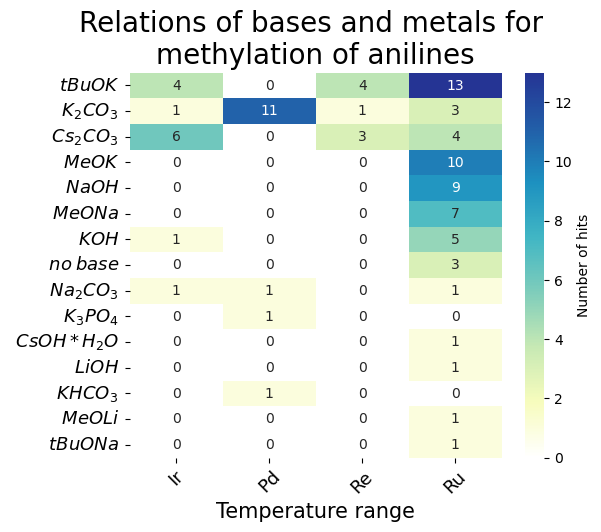

In [138]:
filter_val = 0
pf.d3_diagram(    
    df_meoh.loc[(df_meoh['success']) & (df_meoh['N_source'] == 'aniline')],  
    'base', 
    'metal',
    filter_val = filter_val,
    figsize = (6, 5),
    man_x_label=True,
    x_label = 'Temperature range',
    xlabel_font = 15,
    rotation_x_ticks=45, 
    title_font=20,
    tochem_x = False,
    title = f'Relations of bases and metals for \nmethylation of anilines',
    sort_vertical = True, 
    sort_horizontal = False
)
print(f'Number in the intersection shows the number of successful reactions in this conditions. Bases appeared less than {filter_val } times are neglected')


In [139]:
df_meoh['yield'] = df_meoh['yield_PhNHMe'] + df_meoh['yield_PhN(Me)2']
whole_df = pd.concat([meoh_substr.loc[~meoh_substr['amine_type'].isin(['ArNO2','AlkNO2','HetNO2' ]) ][['metal', 'TON', 'yield',
                                                                                                      'atm_type', 'temp', 'doi', 
                                                                                                       'base', 'catalyst']],
df_meoh.loc[df_meoh['N_source']=='aniline'][['metal', 'TON', 'yield', 
                                       'atmosphere', 'temp', 'doi', 'base', 
                                       'catalyst', 'comment']].rename(columns = {'atmosphere': 'atm_type'})
    
])
metals = list(set(whole_df['metal'].to_list()))
metals = [x for x in metals if (x != '0' and x is not None)]
metal_leaders = []
for metal in metals:
    metal_df = whole_df[whole_df['metal'] == metal]
    metal_df = metal_df.loc[(metal_df['TON'] < 100000) & (metal_df['TON']>5)]
    record = {'metal': metal}
    record['num_papers'] =  len(set(metal_df['doi'].to_list()))
    # max ton maximal TON among all (TONmax(1)/T,°C/base/catalyst typea/atmosphere)
    best = metal_df.sort_values(by = 'TON', ascending = False).to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['max_ton'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['comment']})'
    else:
        record['max_ton'] = 'no data'
    # maximal TON among the processes with preparative yields (TONmax(2)/T,°C/base/catalyst typea/atmosphere)
    best = metal_df[metal_df['yield']>65].sort_values(by = 'TON', ascending = False).to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['max_ton_prep'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['comment']})'
    else:
        record['max_ton_prep'] = 'no data'
    #the lowest temperature in the presence of base (TON/Tmin(1),°C/base/catalyst typea/atmosphere)
    best = metal_df[metal_df['yield']>65].sort_values(by = 'temp').to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['min_temp'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['comment']})'
    else:
        record['min_temp'] = 'no data'
    #the highest TON in the absence of base (TONmax(3)/T,°C/base/catalyst typea/atmosphere)
    best = metal_df[metal_df['base']=='no base'].sort_values(by = 'TON', ascending = False).to_dict('records')
    if len(best):
        best = best[0]  
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['max_ton_no_base'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['comment']})'
    else:
        record['max_ton_no_base'] = 'no data'
        
    #The lowest temperature in the absence of base (TON/Tmin(2),°C/base/catalyst typea/atmosphere)
    best = metal_df.loc[metal_df['base']=='no base'].loc[metal_df['yield']>65].sort_values(by = 'temp').to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['min_temp_no_base'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['comment']})'
    else:
        record['min_temp_no_base'] = 'no data'
    bases = metal_df[metal_df['yield']>65]['base'].value_counts().index.to_list()
    if len(bases) > 1:
        record['most_popular_working_bases']= bases[0:3]
    else:
        record['most_popular_working_bases']= bases
    metal_leaders.append(record)
metal_leaders = sorted(metal_leaders, key = lambda x: x['num_papers'], reverse = True)
metal_leaders = [x for x in metal_leaders if x['num_papers'] > 0]

In [141]:
pd.DataFrame(metal_leaders)

,metal,num_papers,max_ton,max_ton_prep,min_temp,max_ton_no_base,min_temp_no_base,most_popular_working_bases
0,Ru,15,(1000/110.0°C/tBuOK/RuH(CO)Cl(bis(2-(diphenylphosphaneyl)ethyl)amine)/oxygen/10.1021/acs.orglett.8b01449/nan),(1000/110.0°C/tBuOK/RuH(CO)Cl(bis(2-(diphenylphosphaneyl)ethyl)amine)/oxygen/10.1021/acs.orglett.8b01449/nan),(48/60.0°C/NaOH/Ru_11/Air/10.1039/d0cy02210a/nan),(86/180.0°C/no base/RuCl3/oxygen/10.1246/cl.1988.449/nan),(71/180.0°C/no base/RuCl3/oxygen/10.1246/cl.1988.449/nan),"[tBuOK, MeOK, Cs2CO3]"
1,Ir,4,(520/150.0°C/Cs2CO3/Ir_1/N2/10.1021/acs.organomet.2c00125/nan),(368/125.0°C/Cs2CO3/Cp*Ir@CTF/no_data/10.1016/j.jcat.2021.02.030/nan),(136/115.0°C/Cs2CO3/Cp*Ir@CTF/Air/10.1016/j.jcat.2021.02.030/nan),no data,no data,"[Cs2CO3, tBuOK, KOH]"
2,Mn,2,(196/140.0°C/Cs2CO3/Mn_1/inert/10.1002/anie.202318763/nan),(196/140.0°C/Cs2CO3/Mn_1/inert/10.1002/anie.202318763/nan),(80/120.0°C/K2CO3/Mn_1/inert/10.1002/anie.202318763/nan),no data,no data,"[Cs2CO3, K2CO3]"
3,Cu,1,(8/170.0°C/no base/10Cu-5Co/Al2O3/inert/10.1039/d2gc00827k/nan),(8/170.0°C/no base/10Cu-5Co/Al2O3/inert/10.1039/d2gc00827k/nan),(8/170.0°C/no base/10Cu-5Co/Al2O3/inert/10.1039/d2gc00827k/nan),(8/170.0°C/no base/10Cu-5Co/Al2O3/inert/10.1039/d2gc00827k/nan),(8/170.0°C/no base/10Cu-5Co/Al2O3/inert/10.1039/d2gc00827k/nan),[no base]
4,Pd,1,(25/140.0°C/K2CO3/Pd1Cu0.6–Fe3O4/no_data/10.1039/d2cy00065b/nan),(25/140.0°C/K2CO3/Pd1Cu0.6–Fe3O4/no_data/10.1039/d2cy00065b/nan),(19/120.0°C/K2CO3/Pd 1Cu0.6–Fe3O4/no data/10.1039/d2cy00065b/nan),no data,no data,"[K2CO3, KHCO3, K3PO4]"
5,Co,1,(19/160.0°C/tBuOK/Co@NC-800-L1/inert/10.1039/d1sc05913k/nan),(19/160.0°C/tBuOK/Co@NC-800-L1/inert/10.1039/d1sc05913k/nan),(19/160.0°C/tBuOK/Co@NC-800-L1/inert/10.1039/d1sc05913k/nan),no data,no data,[tBuOK]
6,Bi,1,(66/25.0°C/tBuOK/Bi-S3/S-Vs/inert/10.1039/d2ta06142b/nan),(66/25.0°C/tBuOK/Bi-S3/S-Vs/inert/10.1039/d2ta06142b/nan),(66/25.0°C/tBuOK/Bi-S3/S-Vs/inert/10.1039/d2ta06142b/nan),no data,no data,[tBuOK]
7,Re,1,(192/140.0°C/Cs2CO3/Re_3/N2/10.1016/j.jcat.2018.08.008/nan),(192/140.0°C/Cs2CO3/Re_3/N2/10.1016/j.jcat.2018.08.008/nan),(14/130.0°C/tBuOK/Re_1/N2/10.1016/j.jcat.2018.08.008/nan),no data,no data,"[Cs2CO3, tBuOK, K2CO3]"
8,Fe,1,(20/80.0°C/MeOK/FeCl3/inert/10.1039/d2qo00825d/nan),no data,no data,no data,no data,[]


In [143]:
document = Document()
data = metal_leaders
        
sections = document.sections
for section in sections:
    section.orientation = WD_ORIENT.LANDSCAPE

p = document.add_paragraph() 
run = p.add_run('Best catalysts by metals for amine + MeOH processes for all metals and substrates')
run.font.size = Pt(14)
paragraph_format = p.paragraph_format
paragraph_format.alignment = WD_ALIGN_PARAGRAPH.CENTER
p = document.add_paragraph('Data stracture in all cells: (TONmax/T,°C/base/catalyst/atmosphere/doi/comment)') 

col_names = ['Metal', 'Number of papers', 
            'Maximal TON among all ', 
             'Maximal TON among the processes with preparative yields >65%',
                'The lowest temperature among all with preparative yields >65%',
             'The highest TON in the absence of base',
             'The lowest temperature in the absence of base with preparative yields >65%', 
            'most popular working bases']
table = document.add_table(rows= len(data) +1 , cols=len(col_names))
row = table.rows[0]
for idx, col_name in enumerate(col_names):
    
    for p in row.cells[idx].iter_inner_content():
        break
    run = p.add_run(col_name)
    run.bold = True
    
for row_idx, item in enumerate(data):
    row = table.rows[row_idx+1] #так как нулевой ряд - заголовок
    row.cells[0].text = item['metal']
    row.cells[1].text = str(item['num_papers'])
    row.cells[2].text = str(item['max_ton'])
    row.cells[3].text = str(item['max_ton_prep'])
    row.cells[4].text = str(item['min_temp'])
    row.cells[5].text = str(item['max_ton_no_base'])
    row.cells[6].text = str(item['min_temp_no_base'])
    row.cells[7].text = str(item['most_popular_working_bases'])
    

document.save(r'doc_tables/best_cats_amine_MeOH.docx')

In [144]:
whole_df = pd.concat([meoh_substr.loc[meoh_substr['amine_type'].isin(['ArNO2','AlkNO2','HetNO2' ]) ][['metal', 'TON', 'yield',
                                                                                                      'atm_type', 'temp', 'doi', 
                                                                                                       'base', 'catalyst']],
df_meoh.loc[df_meoh['N_source']=='nitroarene'][['metal', 'TON', 'yield', 
                                       'atmosphere', 'temp', 'doi', 'base', 
                                       'catalyst', 'comment']].rename(columns = {'atmosphere': 'atm_type'})
    
])
metals = list(set(whole_df['metal'].to_list()))
metals = [x for x in metals if (x != '0' and x is not None)]
metal_leaders = []
for metal in metals:
    metal_df = whole_df[whole_df['metal'] == metal]
    metal_df = metal_df.loc[(metal_df['TON'] < 100000) & (metal_df['TON']>5)]
    record = {'metal': metal}
    record['num_papers'] =  len(set(metal_df['doi'].to_list()))
    # max ton maximal TON among all (TONmax(1)/T,°C/base/catalyst typea/atmosphere)
    best = metal_df.sort_values(by = 'TON', ascending = False).to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['max_ton'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['comment']})'
    else:
        record['max_ton'] = 'no data'
    # maximal TON among the processes with preparative yields (TONmax(2)/T,°C/base/catalyst typea/atmosphere)
    best = metal_df[metal_df['yield']>65].sort_values(by = 'TON', ascending = False).to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['max_ton_prep'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['comment']})'
    else:
        record['max_ton_prep'] = 'no data'
    #the lowest temperature in the presence of base (TON/Tmin(1),°C/base/catalyst typea/atmosphere)
    best = metal_df[metal_df['yield']>65].sort_values(by = 'temp').to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['min_temp'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['comment']})'
    else:
        record['min_temp'] = 'no data'
    #the highest TON in the absence of base (TONmax(3)/T,°C/base/catalyst typea/atmosphere)
    best = metal_df[metal_df['base']=='no base'].sort_values(by = 'TON', ascending = False).to_dict('records')
    if len(best):
        best = best[0]  
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['max_ton_no_base'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['comment']})'
    else:
        record['max_ton_no_base'] = 'no data'
        
    #The lowest temperature in the absence of base (TON/Tmin(2),°C/base/catalyst typea/atmosphere)
    best = metal_df.loc[metal_df['base']=='no base'].loc[metal_df['yield']>65].sort_values(by = 'temp').to_dict('records')
    if len(best):
        best = best[0]
        ton = best['TON']
        if ton==ton:
            res = round(best['TON'])
        else:
            res = 'no data on TON'
        record['min_temp_no_base'] = f'({res}/{best['temp']}°C/{best['base']}/{best['catalyst']}/{best['atm_type']}/{best['doi']}/{best['comment']})'
    else:
        record['min_temp_no_base'] = 'no data'
    bases = metal_df[metal_df['yield']>65]['base'].value_counts().index.to_list()
    if len(bases) > 1:
        record['most_popular_working_bases']= bases[0:3]
    else:
        record['most_popular_working_bases']= bases
    metal_leaders.append(record)
metal_leaders = sorted(metal_leaders, key = lambda x: x['num_papers'], reverse = True)
metal_leaders = [x for x in metal_leaders if x['num_papers'] > 0]

In [145]:
pd.DataFrame(metal_leaders)

,metal,num_papers,max_ton,max_ton_prep,min_temp,max_ton_no_base,min_temp_no_base,most_popular_working_bases
0,Ru,11,(184/160.0°C/MeOK/Ru_16/N2/10.1002/cctc.202101630/nan),(184/160.0°C/MeOK/Ru_16/N2/10.1002/cctc.202101630/nan),(20/100.0°C/tBuOK/Ru_23/air/10.1039/d3cy00218g/nan),(25/130.0°C/no base/Ru_23/N2/10.1039/d3cy00218g/nan),(25/130.0°C/no base/Ru_23/N2/10.1039/d3cy00218g/nan),"[tBuOK, MeONa, Cs2CO3]"
1,Pd,2,(85/110.0°C/KOH/Pd(OAc)2/inert/10.1002/anie.201814146/nan),(85/110.0°C/KOH/Pd(OAc)2/inert/10.1002/anie.201814146/nan),(82/80.0°C/KOH/Pd(OAc)2/inert/10.1002/anie.201814146/nan),no data,no data,"[KOH, K3PO4, CsOH]"
2,Ir,2,(140/190.0°C/tBuOK/Ir@YSMCNs/Air/10.1002/ajoc.201900140/nan),(140/190.0°C/tBuOK/Ir@YSMCNs/Air/10.1002/ajoc.201900140/nan),(114/130.0°C/K2CO3/Cp*Ir(N^N)Cl2/inert/10.1021/acs.joc.1c02625/nan),no data,no data,"[tBuOK, K2CO3]"
3,Mn,1,(48/150.0°C/Cs2CO3/Mn_1/inert/10.1021/acs.orglett.2c03595/nan),(48/150.0°C/Cs2CO3/Mn_1/inert/10.1021/acs.orglett.2c03595/nan),(24/140.0°C/Cs2CO3/MnBr(CO)5/Ar/10.1021/acs.orglett.2c03595/nan),no data,no data,[Cs2CO3]
4,Pt,1,(48/150.0°C/NaOH/5 wt.% Pt/C/oxygen/10.1021/acs.joc.2c02657/nan),(48/150.0°C/NaOH/5 wt.% Pt/C/oxygen/10.1021/acs.joc.2c02657/nan),(48/150.0°C/NaOH/5 wt.% Pt/C/oxygen/10.1021/acs.joc.2c02657/nan),no data,no data,[NaOH]


In [146]:
document = Document()
data = metal_leaders
        
sections = document.sections
for section in sections:
    section.orientation = WD_ORIENT.LANDSCAPE

p = document.add_paragraph() 
run = p.add_run('Best catalysts by metals for nitroarene + MeOH process for all catalysts and metals')
run.font.size = Pt(14)
paragraph_format = p.paragraph_format
paragraph_format.alignment = WD_ALIGN_PARAGRAPH.CENTER
p = document.add_paragraph('Data stracture in all cells: (TONmax/T,°C/base/catalyst/atmosphere/doi/comment)') 

col_names = ['Metal', 'Number of papers', 
            'Maximal TON among all ', 
             'Maximal TON among the processes with preparative yields >65%',
                'The lowest temperature among all with preparative yields >65%',
             'The highest TON in the absence of base',
             'The lowest temperature in the absence of base with preparative yields >65%', 
            'most popular working bases']
table = document.add_table(rows= len(data) +1 , cols=len(col_names))
row = table.rows[0]
for idx, col_name in enumerate(col_names):
    
    for p in row.cells[idx].iter_inner_content():
        break
    run = p.add_run(col_name)
    run.bold = True
    
for row_idx, item in enumerate(data):
    row = table.rows[row_idx+1] #так как нулевой ряд - заголовок
    row.cells[0].text = item['metal']
    row.cells[1].text = str(item['num_papers'])
    row.cells[2].text = str(item['max_ton'])
    row.cells[3].text = str(item['max_ton_prep'])
    row.cells[4].text = str(item['min_temp'])
    row.cells[5].text = str(item['max_ton_no_base'])
    row.cells[6].text = str(item['min_temp_no_base'])
    row.cells[7].text = str(item['most_popular_working_bases'])
    

document.save(r'doc_tables/best_cats_nitroarene_MeOH.docx')